# SBERT Sentence Analysis

## 1. Preparations

### 1.1 Read Data
This new data is obtained after some further anonymization, and by putting previously incorrectly split sentences together, and removed duplicates

In [2]:
import pandas as pd
# read the sentence data 
df = pd.read_excel("/workspace/persistent/mijnidbcoachnlp/data/analysis_data/translated_sentence_data_new.xlsx")
# check the head
df.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence
0,3,Ik ben 2 weken geleden met spoed opgenomen in ...,Ik ben 2 weken geleden met spoed opgenomen in ...,1,I was rushed into the [PRESSION] two weeks ago...
1,3,"Ik kreeg acuut een pijnlijke druk op de borst,...","Ik kreeg acuut een pijnlijke druk op de borst,...",2,I was acutely under a painful pressure on the ...
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,3,It started 1 hour after dinner.
3,3,"Ik had al de hele dag migraine, had dus ook we...","Ik had al de hele dag migraine, had dus ook we...",4,"I had migraines all day, so I hadn't eaten much."
4,3,"Ik werd heel erg misselijk, braakneigingen, du...","Ik werd heel erg misselijk, braakneigingen, du...",5,"I got very nauseous, vomiting, dizzy and rejuv..."


In [3]:
# clean sentences as inputs
sentences = df["Clean_Sentence"].to_list()

In [4]:
# print the size of the data
len(sentences)
# There are 41143 sentences 

41143

### 1.2. Import the list of stopwords

In [5]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/persistent/mijnidbcoachnlp/data/analysis_data/stopwords.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

extra_list = [
    'maandag', 'dinsdag', 'woensdag', 'donderdag', 'vrijdag', 'zaterdag', 'zondag',
    'januari', 'februari', 'maart', 'april', 'mei', 'juni', 'juli', 'augustus', 'september', 'oktober', 'november', 'december',
    'jan', 'feb', 'mrt', 'apr', 'mei', 'jun', 'jul', 'aug', 'sep', 'okt', 'nov', 'dec', "jl", "weken", "week", "dagen", "dag", "mg", "coach", "mijnibdcoach", "dr", "uur", "dgs"
]

dutch_stopwords.extend(extra_list)

### 1.4. Embed the lists of sentences with sentence-transformer multilingual-v1

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

# load the embedding model
embedding_model = SentenceTransformer("distiluse-base-multilingual-cased-v1")

# run the following for embeddings if no pre-saved embeddings can be loaded
#embeddings = embedding_model.encode(sentences, show_progress_bar=True)
# save the pre-calculated embeddings 
#np.save('/workspace/mijnidbcoachnlp/data/embeddings/embeddings_st_v1_new_input.npy', embeddings)

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np
# load pre-saved embeddings if you have, otherwise calculate them using the commented-out codes
embedding_model = SentenceTransformer("distiluse-base-multilingual-cased-v1")
embeddings = np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v1_new_input.npy")

In [8]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Create a dictionary representation of the words in topics
tokenized_texts = [doc.split() for doc in sentences]  # Tokenizing by splitting on spaces
dictionary = Dictionary(tokenized_texts)

def get_top_words(topic_model):
    topics = topic_model.get_topics()
    top_words = [[word for word, _ in topic[:10]] for topic in topics.values() if topic]  # Top 10 words per topic
    return top_words

def calculate_c_v(topic_model):
    top_words = get_top_words(topic_model)
    coherence_model = CoherenceModel(topics=top_words, 
                                texts=tokenized_texts,
                                dictionary=dictionary, 
                                coherence='c_v')
    coherence_score = coherence_model.get_coherence()
    return coherence_score

In [9]:
# disable parallelism to avoid some warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## 2. Fine-tune the ST model

In [15]:
import random
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# Precompute embeddings (this part depends on your chosen embedding model)
# Example: Assuming 'embeddings' is already computed and available
# embeddings = embedding_model.encode(sentences)

# Initialize BERTopic with the pre-fit vectorizer
topic_model = BERTopic()

# Define parameter ranges
range_n_neighbors = [10, 20, 30, 40, 50]
range_n_components = [2, 3, 4, 5, 6]
range_min_dist = [0.0, 0.05, 0.1]

# Number of random configurations to generate
num_configs = 3  # Adjust this as needed

# Generate random UMAP configurations
umap_configs = [
    {
        "n_neighbors": random.choice(range_n_neighbors),
        "n_components": random.choice(range_n_components),
        "min_dist": random.choice(range_min_dist),
    }
    for _ in range(num_configs)
]

# Define the ranges for HDBSCAN configurations
range_min_cluster_size = [10, 20, 30]  # Example values
range_min_samples = [10, 20, 30]  # Example values

# Generate random HDBSCAN configurations
hdbscan_configs = [
    {
        "min_cluster_size": random.choice(range_min_cluster_size),
        "min_samples": random.choice([x for x in range_min_samples if x <= random.choice(range_min_cluster_size)]),
    }
    for _ in range(num_configs)
]

# Initialize a dictionary to keep track of configurations and their associated coherence scores
tried_configs = {}

# Optionally, load previously tried configurations from a file (if running multiple times)
try:
    with open("tried_configs_st.pkl", "rb") as f:
        tried_configs = pickle.load(f)
except FileNotFoundError:
    pass  # If no previous file exists, we start fresh

# Variables to track the best model
best_topic_model = None
best_coherence_score = -float('inf')  # Initializing to a very low score
best_configure = None

# Set the outlier thresholds (upper and lower)
upper_outlier_threshold = 0.5  # Maximum allowed outlier percentage (5% of points)
lower_outlier_threshold = 0.2  # Minimum allowed outlier percentage (2% of points)

In [17]:
# Fine-tuning loop
for umap_params in umap_configs:
    for hdbscan_params in hdbscan_configs:
        config_tuple = (frozenset(umap_params.items()), frozenset(hdbscan_params.items()))

        # Skip if the configuration has already been tried
        if config_tuple in tried_configs:
            print(f"Skipping already tried configuration: {umap_params}, {hdbscan_params}")
            continue

        # Initialize UMAP and HDBSCAN with current configurations
        umap_model = UMAP(**umap_params)
        hdbscan_model = HDBSCAN(**hdbscan_params)
        print(f"Fitting model for UMAP {umap_params} and HDBSCAN {hdbscan_params}")

        # Update BERTopic with the new UMAP and HDBSCAN models
        topic_model.umap_model = umap_model
        topic_model.hdbscan_model = hdbscan_model
        topic_model.vectorizer_model = CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b')
        topic_model.calculate_probabilities = False

        # Fit the model
        topics, probs = topic_model.fit_transform(sentences, embeddings)

        # Calculate coherence score
        current_coherence_score = calculate_c_v(topic_model)

        # Check if the model has at least 20 topics
        num_topics = len(topic_model.get_topics())
        if num_topics < 20:
            print(f"Skipping model with {num_topics} topics (less than 20).")
            tried_configs[config_tuple] = "skipped"
            continue

        # Check outlier percentage
        outlier_cluster_size = sum(1 for label in hdbscan_model.labels_ if label == -1)
        outlier_percentage = outlier_cluster_size / len(hdbscan_model.labels_)
        
        if outlier_percentage > upper_outlier_threshold:
            print(f"Skipping model with {outlier_percentage * 100}% outliers (above {upper_outlier_threshold * 100}%).")
            tried_configs[config_tuple] = "skipped"
            continue
        elif outlier_percentage < lower_outlier_threshold:
            print(f"Skipping model with {outlier_percentage * 100}% outliers (below {lower_outlier_threshold * 100}%).")
            tried_configs[config_tuple] = "skipped"
            continue
        
        # Store the valid configuration and score
        tried_configs[config_tuple] = current_coherence_score

        # Update best model
        if current_coherence_score > best_coherence_score:
            best_coherence_score = current_coherence_score
            best_topic_model = topic_model
            best_configure = (umap_params, hdbscan_params)

        print(f"Coherence score: {current_coherence_score}\n")

        # Save tried configurations after every iteration
        with open("tried_configs_st.pkl", "wb") as f:
            pickle.dump(tried_configs, f)


Fitting model for UMAP {'n_neighbors': 50, 'n_components': 4, 'min_dist': 0.05} and HDBSCAN {'min_cluster_size': 10, 'min_samples': 10}
Coherence score: 0.3662643130528934

Fitting model for UMAP {'n_neighbors': 50, 'n_components': 4, 'min_dist': 0.05} and HDBSCAN {'min_cluster_size': 10, 'min_samples': 20}
Coherence score: 0.35050085496611455

Fitting model for UMAP {'n_neighbors': 50, 'n_components': 4, 'min_dist': 0.05} and HDBSCAN {'min_cluster_size': 30, 'min_samples': 10}
Coherence score: 0.3582903721014854

Fitting model for UMAP {'n_neighbors': 20, 'n_components': 4, 'min_dist': 0.1} and HDBSCAN {'min_cluster_size': 10, 'min_samples': 10}
Coherence score: 0.3666985394181407

Fitting model for UMAP {'n_neighbors': 20, 'n_components': 4, 'min_dist': 0.1} and HDBSCAN {'min_cluster_size': 10, 'min_samples': 20}
Coherence score: 0.36657597532332886

Fitting model for UMAP {'n_neighbors': 20, 'n_components': 4, 'min_dist': 0.1} and HDBSCAN {'min_cluster_size': 30, 'min_samples': 10}


In [18]:
# After the loop, print the best configurations and score
print("Best UMAP and HDBSCAN configurations based on coherence score:")
print(f"Best Coherence Score: {best_coherence_score}")
print(f"Best UMAP Params: {best_configure[0]}")
print(f"Best HDBSCAN Params: {best_configure[1]}")

Best UMAP and HDBSCAN configurations based on coherence score:
Best Coherence Score: 0.368752327810459
Best UMAP Params: {'n_neighbors': 20, 'n_components': 3, 'min_dist': 0.05}
Best HDBSCAN Params: {'min_cluster_size': 10, 'min_samples': 10}


In [20]:
import pickle

# Load the file
with open("tried_configs_st.pkl", "rb") as f:
    tried_configs = pickle.load(f)

# Print the contents
for config, score in tried_configs.items():
    print(f"Config: {config}, Score: {score}")


Config: (frozenset({('n_neighbors', 10), ('min_dist', 0.1), ('n_components', 5)}), frozenset({('min_cluster_size', 30), ('min_samples', 10)})), Score: 0.3425443099837642
Config: (frozenset({('n_neighbors', 10), ('n_components', 4), ('min_dist', 0.0)}), frozenset({('min_samples', 30), ('min_cluster_size', 20)})), Score: 0.35067638061555395
Config: (frozenset({('n_neighbors', 10), ('n_components', 4), ('min_dist', 0.0)}), frozenset({('min_cluster_size', 30), ('min_samples', 10)})), Score: 0.3362990734428644
Config: (frozenset({('n_neighbors', 10), ('n_components', 4), ('min_dist', 0.0)}), frozenset({('min_samples', 30), ('min_cluster_size', 10)})), Score: 0.3490907784930923
Config: (frozenset({('n_neighbors', 10), ('n_components', 3), ('min_dist', 0.0)}), frozenset({('min_samples', 30), ('min_cluster_size', 20)})), Score: 0.33991947203180106
Config: (frozenset({('n_neighbors', 10), ('n_components', 3), ('min_dist', 0.0)}), frozenset({('min_cluster_size', 30), ('min_samples', 10)})), Scor

In [23]:
best_topic_model.save("/workspace/persistent/mijnidbcoachnlp/saved_models/best_cv_score_st_model", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

In [24]:
calculate_c_v(best_topic_model)

0.3552550163346731

In [21]:
best_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18597,-1_afspraak_vraag_gaat_weet,"[afspraak, vraag, gaat, weet, volgende, goed, ...","[en/of , Het gaat de laatste 2 weken niet zo g..."
1,0,3367,0_bloed_prikken_bloedprikken_ontlasting,"[bloed, prikken, bloedprikken, ontlasting, sli...",[Afgelopen vrijdag ben ik bloed laten prikken....
2,1,1291,1_huisarts_arts_dokter_mdl,"[huisarts, arts, dokter, mdl, ziekenhuis, cont...","[Ja bij mijn huisarts., Ja bij mijn huisarts.,..."
3,2,556,2_medicatie_apotheek_medicijnen_medicijn,"[medicatie, apotheek, medicijnen, medicijn, re...","[Nog steeds geen recept binnen bij apotheek!, ..."
4,3,516,3_pijn_buikpijn_pijnlijk_buik,"[pijn, buikpijn, pijnlijk, buik, pijnlijke, ru...","[Dit is ondoenlijk van wege de pijn!, Maar ik ..."
...,...,...,...,...,...
242,241,11,241_doorgestuurd_apotheekderrein_zorginstellin...,"[doorgestuurd, apotheekderrein, zorginstelling...",[Het recept van de picoprep zou zijn doorgestu...
243,242,11,242_optie_rele_alternatieve_buitenland,"[optie, rele, alternatieve, buitenland, vastge...","[Zijn er nog andere optie?, Is dit een reële o..."
244,243,10,243_verwachtte_kim_beloofd_schrijft,"[verwachtte, kim, beloofd, schrijft, weekend, ...",[Ik had beloofd nog even te laten weten hoe he...
245,244,10,244_contactmoment_emailen_vlg_simpony,"[contactmoment, emailen, vlg, simpony, kontakt...",[ik heb vorige week via de mail nieuwe simpon...


In [25]:
# check if reduce outliers now work
# Reduce outliers
topics = best_topic_model.topics_
new_topics = best_topic_model.reduce_outliers(sentences, topics)

In [26]:
best_topic_model.update_topics(sentences, topics=new_topics, vectorizer_model=CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'))

2025-02-13 05:22:51,663 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [27]:
# check topic_info after outlier reduction
best_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,259,-1_verstandigst_trant_heermevrouw_aangenaam,"[verstandigst, trant, heermevrouw, aangenaam, ...","[en/of , Het gaat de laatste 2 weken niet zo g..."
1,0,3567,0_bloed_prikken_ontlasting_bloedprikken,"[bloed, prikken, ontlasting, bloedprikken, sli...",[Afgelopen vrijdag ben ik bloed laten prikken....
2,1,1458,1_huisarts_arts_dokter_mdl,"[huisarts, arts, dokter, mdl, ziekenhuis, cont...","[Ja bij mijn huisarts., Ja bij mijn huisarts.,..."
3,2,650,2_medicatie_medicijn_apotheek_medicijnen,"[medicatie, medicijn, apotheek, medicijnen, vo...","[Nog steeds geen recept binnen bij apotheek!, ..."
4,3,694,3_pijn_buikpijn_pijnlijk_buik,"[pijn, buikpijn, pijnlijk, buik, pijnlijke, ru...","[Dit is ondoenlijk van wege de pijn!, Maar ik ..."
...,...,...,...,...,...
242,241,36,241_doorgestuurd_picoprep_gestuurd_doorgezet,"[doorgestuurd, picoprep, gestuurd, doorgezet, ...",[Het recept van de picoprep zou zijn doorgestu...
243,242,75,242_optie_alternatief_momenten_mogelijkheden,"[optie, alternatief, momenten, mogelijkheden, ...","[Zijn er nog andere optie?, Is dit een reële o..."
244,243,61,243_nou_wekelijks_geplande_volgen,"[nou, wekelijks, geplande, volgen, geval, inna...",[Ik had beloofd nog even te laten weten hoe he...
245,244,48,244_gelezen_laboratorium_buikgriep_afgesproken,"[gelezen, laboratorium, buikgriep, afgesproken...",[ik heb vorige week via de mail nieuwe simpon...


In [28]:
best_topic_model.save("/workspace/persistent/mijnidbcoachnlp/saved_models/best_cv_score_st_model_ro", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

In [29]:
calculate_c_v(best_topic_model)

0.3566552534427884

# map the topics to one of the two labels

In [171]:
from bertopic import BERTopic
topic_model = BERTopic.load("/workspace/persistent/mijnidbcoachnlp/saved_models/best_cv_score_st_model_ro", embedding_model=embedding_model)

In [172]:
og_topic_info = topic_model.get_topic_info()

In [173]:
# settings for plotly
import plotly.io as pio
pio.renderers.default = "notebook"
pio.renderers.default = "browser" # option to open the plots in brower

# visualize the hierarchy and manually merge some topics
hierarchical_topics = topic_model.hierarchical_topics(sentences)
#topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 245/245 [00:01<00:00, 167.28it/s]


In [174]:
# Reduce the topics with a similarity threshold < 0.5
threshold = 0.5 # Define the threshold for merging
filtered_hierarchical_topics = hierarchical_topics[hierarchical_topics["Distance"] <= threshold]

# Ensure the loop stops when no more topics can be merged
while not filtered_hierarchical_topics.empty:  

    list_topics_to_merge = filtered_hierarchical_topics["Topics"].to_list()

    # Merge topics
    topic_model.merge_topics(sentences, list_topics_to_merge)

    # Recompute hierarchical topics after merging
    hierarchical_topics = topic_model.hierarchical_topics(sentences)

    # Update the filtered topics for the next iteration
    filtered_hierarchical_topics = hierarchical_topics[hierarchical_topics["Distance"] <= threshold]


100%|██████████| 208/208 [00:01<00:00, 168.58it/s]


In [175]:
topic_info  = topic_model.get_topic_info()
topic_info[topic_info["Name"].str.contains("thuistes")]

,Topic,Count,Name,Representation,Representative_Docs
43,42,243,42_thuis_thuistest_huis_liggen,"[thuis, thuistest, huis, liggen, gedaan, calpro, werk, ziek, uitvoeren, werkgever]","[Nee ik heb niks meer in huis heb wel nog thuistest hier, Ik heb deze thuistest nog niet in huis., Ik heb nog 1 thuistest thuis liggen.]"
106,105,127,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]"


In [176]:
doc_info = topic_model.get_document_info(sentences)
pd.set_option("display.max_colwidth", None)
doc_info[doc_info["Topic"] == 105]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Representative_document
164,Ik moet nog voor een nieuwe boven en ondergebit en ik moet er ook 7 tanden laten treken dat weten de Dokters in [ZIEKENHUIS],105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
322,"Heel fijn, zou u mij ook nog 3 of 4 thuistesten kunnen sturen?",105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
1131,Zouden jullie ook een verwijzing kunnen maken voor de oogarts?,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
1292,Moet ik dan nog een nieuwe voorraad Co-Trimoxazol krijgen?,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
1454,Als die op zijn heb ik dan nog nieuwe nodig?,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
...,...,...,...,...,...,...,...
39767,Het kan een algemene ziekteverklaring zijn; die met het oog op de toekomst ook bruikbaar is.,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
39825,Zouden jullie het opnieuw kunnen sturen?,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
40318,Is het een mogelijkheid dat jullie een verwijzing sturen naar die poli?,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen., Thuistesten wel nog !]",thuistesten - verwijzing - versturen - nieuwe - oog - ontstoken - nogmaals - huisadres - zalf - terugbellen,False
40547,Tja het is natuurlijk de vraag of die thuistesten het weer doen.,105,105_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, oog, ontstoken, nogmaals, huisadres, zalf, terugbellen]","[Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe

In [177]:
# settings for plotly
import plotly.io as pio
pio.renderers.default = "notebook"
pio.renderers.default = "browser" # option to open the plots in brower

# visualize the hierarchy and manually merge some topics
hierarchical_topics = topic_model.hierarchical_topics(sentences)
#topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 208/208 [00:01<00:00, 163.85it/s]


In [178]:
topics_to_merge_manually = [[190, 25],#food, appetite
[65, 3],# GI symptoms
[108, 54], #sleep
[171, 7, 89, 83, 57, 115, 60, 5, 93], #medicine/medication use
[92, 90, 2], #pharmacy and prescription
[193, 107, 173, 70], # telephone contact
[180, 87, 151], # vitamins and minerals
[197, 59], #inquire of test results
[80, 72], # advice
[113, 156, 18], # coronavirus & vaccine
[124, 142], #fever
[11, 130], # quetion/questionaire
[42, 94, 14, 183], #calprotectin home-test
[189, 20, 149, 162, 55, 102, 167, 208, 154, 53, 109, 187, 98, 78, 52, 101, 23, 22, 179] # sign-offs and greetings
]
topic_model.merge_topics(sentences, topics_to_merge_manually)


In [82]:
topic_info = topic_model.get_topic_info()
topic_info[topic_info["Name"].str.contains("thuistes")]

,Topic,Count,Name,Representation,Representative_Docs
87,86,127,86_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, n...","[Ik heb de thuistesten ontvangen., Thuistesten..."


In [122]:
topic_names = topic_model.get_topic_info()["Name"].to_list()
topic_names

['-1_verstandigst_trant_aangenaam_zenuwachtig',
 '0_bloed_prikken_ontlasting_slijm',
 '1_dank_bedankt_reactie_snelle',
 '2_medicatie_gebruik_tabletten_daags',
 '3_huisarts_arts_dokter_mdl',
 '4_recept_apotheek_nieuw_sturen',
 '5_pijn_buikpijn_buik_pijnlijk',
 '6_thuis_cal_quanton_vorige',
 '7_hoor_graag_horen_alvast',
 '8_merk_last_tijd_laatste',
 '9_vraag_vragen_vraagje_vragenlijst',
 '10_voel_gevoel_voelt_voelen',
 '11_corona_vaccin_vaccinatie_positief',
 '12_contact_telefonisch_opnemen_consult',
 '13_gepland_staan_poli_afspraak',
 '14_wacht_hoop_wachten_hopelijk',
 '15_telefoon_bereikbaar_nummer_oproep',
 '16_klachten_kleine_vermoeidheid_dun',
 '17_goed_gaat_ging_algemeen',
 '18_test_gedaan_zelftest_testen',
 '19_eten_eet_eetlust_drinken',
 '20_sessie_uitnodiging_afspraak_nieuwe',
 '21_advies_adviseren_overleggen_overleg',
 '22_nacht_wakker_slaap_vannacht',
 '23_toilet_diarree_vaker_aandrang',
 '24_infuus_komende_echo_vanmiddag',
 '25_weten_laat_laten_duidelijkheid',
 '26_afspraak_v

In [179]:

# visualize the hierarchy and manually merge some topics
hierarchical_topics = topic_model.hierarchical_topics(sentences)
#topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 163/163 [00:00<00:00, 181.83it/s]


In [143]:
doc_info = topic_model.get_document_info(sentences)
pd.set_option("display.max_colwidth", None)
doc_info[doc_info["Topic"] == 45]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Representative_document
456,Ik heb dus morgen een buisje bij me met ontlasting alleen heb ik geen formulier erbij.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
566,Ik zal bij de eerst volgende keer potje ontlasting meenemen.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
629,Ik heb pas een ontlastingformulier ontvangen met een potje.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
662,ik ben weer aan mijn laatste potje purinethol toe.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
733,"Laboratoriumformulieren heb ik niet, potje wel..",45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
...,...,...,...,...,...,...,...
40350,Ook heb ik een formulier gekregen voor de ontlasting.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
40440,"Nee heb geen potje meer, zou u deze kunnen opsturen.",45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
40615,Ik heb geen lab formulieren/buisjes meer.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potjes - lab - buisje - ontvangen - bezit - prikformulieren - informatiefolder,False
40623,Ik heb het formulier en potje nog niet ontvangen.,45,45_potje_formulier_formulieren_potjes,"[potje, formulier, formulieren, potjes, lab, buisje, ontvangen, bezit, prikformulieren, informatiefolder]","[Ik heb nog een formulier en potje., Formulier en potje heb ik., Ja ik heb nog een potje en een formulier.]",potje - formulier - formulieren - potj

In [180]:
topics_to_merge_manually_2 = [[5, 131], # GI symptoms
[16, 8], # general symptoms
[34, 23], # diarrhea
[101, 3], # hospital/doctor visit
[20, 26, 13, 50], # appointment/session
[88, 95, 74], # calprotectin value
[18, 6], # home test
[45, 37], # stool sampling forms and papers
[29, 89, 134], # mail and address
[162, 67, 1], # sign-offs
[56, 104], # non-actionable 
]
topic_model.merge_topics(sentences, topics_to_merge_manually_2)


In [181]:
topic_info = topic_model.get_topic_info()
topic_info[topic_info["Name"].str.contains("thuis")]

,Topic,Count,Name,Representation,Representative_Docs
7,6,1239,6_test_thuis_gedaan_quanton,"[test, thuis, gedaan, quanton, cal, testen, thuistest, huis, vorige, zelftest]","[De test was echter nog niet over de datum., Moet ik deze test nu doen ?, Ik heb inderdaad nog een test thuis.]"
78,77,127,77_thuistesten_verwijzing_versturen_nieuwe,"[thuistesten, verwijzing, versturen, nieuwe, nogmaals, oog, ontstoken, huisadres, sturen, zalf]","[Thuistesten wel nog !, Ik heb twee thuistesten., Nu was mijn vraag of ik nieuwe thuistesten kan krijgen.]"


In [182]:

# visualize the hierarchy and manually merge some topics
hierarchical_topics = topic_model.hierarchical_topics(sentences)
#topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 147/147 [00:00<00:00, 179.73it/s]


In [148]:
topic_names = topic_model.get_topic_info()["Name"].to_list()
topic_names

['-1_verstandigst_trant_aangenaam_zenuwachtig',
 '0_bloed_prikken_ontlasting_slijm',
 '1_bedankt_dank_reactie_snelle',
 '2_medicatie_gebruik_tabletten_medicijnen',
 '3_huisarts_arts_dokter_mdl',
 '4_afspraak_gepland_sessie_poli',
 '5_recept_apotheek_nieuw_sturen',
 '6_test_thuis_gedaan_quanton',
 '7_pijn_buikpijn_buik_pijnlijk',
 '8_klachten_merk_last_tijd',
 '9_hoor_graag_horen_alvast',
 '10_toilet_keer_diarree_vaker',
 '11_vraag_vragen_vraagje_vragenlijst',
 '12_voel_gevoel_voelt_voelen',
 '13_corona_vaccinatie_vaccin_positief',
 '14_contact_telefonisch_opnemen_consult',
 '15_formulieren_formulier_potje_papieren',
 '16_mail_brief_adres_bericht',
 '17_wacht_hoop_wachten_hopelijk',
 '18_telefoon_bereikbaar_nummer_oproep',
 '19_goed_gaat_ging_algemeen',
 '20_calprotectine_waarde_waardes_bekend',
 '21_eten_eet_eetlust_drinken',
 '22_advies_adviseren_overleggen_graag',
 '23_nacht_wakker_slaap_vannacht',
 '24_infuus_komende_echo_vanmiddag',
 '25_weten_laat_laten_duidelijkheid',
 '26_crohn_

In [183]:
doc_info = topic_model.get_document_info(sentences)
pd.set_option("display.max_colwidth", 200)
doc_info[doc_info["Topic"] == 57]

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Representative_document
458,Half 10 heb ik de echo.,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
495,"en , Op 6 april om 22:37 uur ben ik bevallen van onze dochter .",57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
1257,Sinds de scopie van 2 november zijn mijn darmklachten verslechterd.,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
1259,Enige pluspuntje is dat ik sinds 7 november 's nachts af en toe scheetjes laat want dat ging vanaf eind oktober niet meer.,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
1267,sinds zaterdag 11 november gebruik ik een verhoogd schema prednisolon.,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
...,...,...,...,...,...,...,...
40430,oktober/november 2021 ben ik op controle geweest bij .,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
40528,In januari heb ik een afspraak opstaan en daarvoor heb ik een lab briefje gekregen.,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
40554,Dus dat zou dan ook eind februari zijn,57,57_telefonische_eind_opstaan_verzet,"[telefonische, eind, opstaan, verzet, entocort, half, bevallen, afspraak, dochter, kom]","[Moet ik zelf een telefonische afspraak maken?, Afgelopen maandag had ik een telefonische afspraak met ., Afgelopen maandag 20-12 zou ik een telefonische afspraak hebben met .]",telefonische - eind - opstaan - verzet - entocort - half - bevallen - afspraak - dochter - kom,False
40810,De laatste medicatie is ent

In [184]:
# large merge
topics_to_merge_manually_3 = [[145, 147, 9, 123], # hoor graag
[25, 68], # want to know
[33, 34], # results inquiry
[102, 42], # weet
[92, 55], # thought process
[143, 1],
[78, 100], # operation
[18, 63, 59, 39, 44, 4, 57] # appointment and contact
]
topic_model.merge_topics(sentences, topics_to_merge_manually_3)


In [185]:
topic_model.get_topic_info()[:10]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,259,-1_verstandigst_trant_aangenaam_zenuwachtig,"[verstandigst, trant, aangenaam, zenuwachtig, onderwerpen, genegeerd, docter, dexamfetamine, glucose, hogen]","[Of iets in die trant., Wat is voor mij het verstandigst., Of iets in die trant.]"
1,0,3567,0_bloed_prikken_ontlasting_laten,"[bloed, prikken, ontlasting, laten, slijm, bloedprikken, ingeleverd, bloeduitslagen, geprikt, inleveren]","[ik nooit meer bloed te laten prikken?, Afgelopen maandag 4 juli heb ik bloed laten prikken via ., Maar moet ik niet ook nog bloed laten prikken?]"
2,1,3130,1_bedankt_dank_reactie_snelle,"[bedankt, dank, reactie, snelle, alvast, bericht, antwoord, dankjewel, fijn, weekend]","[heer , Oké, dank u voor de snelle reactie!, Alvast dank voor uw reactie, Fijn bedankt voor snelle reactie]"
3,2,2871,2_afspraak_bellen_proberen_bereikbaar,"[afspraak, bellen, proberen, bereikbaar, gepland, poli, vandaag, telefoon, staan, staat]","[Ik zal een afspraak maken., De afspraak is inmiddels op een andere dag vastgezet., Ik heb afgelopen vrijdag een afspraak met gehad.]"
4,3,2298,3_medicatie_gebruik_tabletten_medicijnen,"[medicatie, gebruik, tabletten, medicijnen, daags, gebruiken, pentasa, tablet, apotheek, medicijn]","[Graag zou ik andere medicatie willen., ik zou graag een recept voor 3 maanden willen hebben van : Azathioprine 25 mg 1 x daags 1 tablet Azathioprine 50 mg 1 x daags 2 tablet Forlax 10 gram 4 x da..."
5,4,1559,4_huisarts_arts_dokter_mdl,"[huisarts, arts, dokter, mdl, ziekenhuis, contact, verpleegkundige, medische, afspraak, behandeling]","[De huisarts vroeg zich af of dit kan door ., Ik ben afgelopen vrijdag weer bij de huisarts geweest., Ja via de huisarts.]"
6,5,1347,5_recept_apotheek_nieuw_sturen,"[recept, apotheek, nieuw, sturen, herhaalrecept, faxen, purinethol, nethol, puri, aanvragen]","[Kunt u een nieuw recept sturen naar apotheek ?, Kunnen jullie a.u.b. een nieuw recept naar de apotheek sturen., Zou u anders een nieuw recept kunnen sturen naar mijn apotheek?]"
7,6,1239,6_test_thuis_gedaan_quanton,"[test, thuis, gedaan, quanton, cal, testen, vorige, thuistest, huis, zelftest]","[Moet ik deze test nu doen ?, De test was echter nog niet over de datum., Ik heb inderdaad nog een test thuis.]"
8,7,1088,7_pijn_buikpijn_buik_pijnlijk,"[pijn, buikpijn, buik, pijnlijk, last, pijnlijke, rug, gevoel, onderbuik, hoofdpijn]","[Geen pijn meer in., Maar ik heb af en toe meer pijn., Deze doet niet pijn, het groeit wel.]"
9,8,1012,8_klachten_merk_last_tijd,"[klachten, merk, last, tijd, darmen, laatste, vermoeidheid, kleine, geworden, dun]","[ik heb de laatste tijd weer meer last van mijn buik., Ik heb de laatste dagen meer klachten van mijn darmen., Nu merk ik sinds gisteren dat ik meer last heb van mijn darmen.]"


In [186]:
# large merge
topics_to_merge_manually_4 = [[106, 78, 7, 8, 39, 24, 10, 66], # symptoms and complaints
[0, 6], # stool and blood test
[21, 15, 63], # calprotectin home test
[14, 2], #contact and appointment
]
topic_model.merge_topics(sentences, topics_to_merge_manually_4)


In [187]:

# visualize the hierarchy and manually merge some topics
hierarchical_topics = topic_model.hierarchical_topics(sentences)
#topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

100%|██████████| 121/121 [00:00<00:00, 180.33it/s]


In [188]:

topic_info = topic_model.get_topic_info()

In [189]:
topic_info = topic_model.get_topic_info()
topic_names = topic_info["Name"].to_list()
topic_names

['-1_verstandigst_trant_aangenaam_zenuwachtig',
 '0_bloed_prikken_ontlasting_test',
 '1_pijn_buikpijn_toilet_last',
 '2_afspraak_telefonisch_contact_bellen',
 '3_bedankt_dank_reactie_snelle',
 '4_medicatie_gebruik_tabletten_medicijnen',
 '5_huisarts_arts_dokter_mdl',
 '6_recept_apotheek_nieuw_sturen',
 '7_bekend_calprotectine_uitslag_waarde',
 '8_hoor_graag_horen_verneem',
 '9_vraag_vragen_vraagje_vragenlijst',
 '10_voel_gevoel_voelt_voelen',
 '11_corona_vaccinatie_vaccin_positief',
 '12_formulieren_formulier_potje_papieren',
 '13_mail_brief_adres_bericht',
 '14_weten_laat_vertellen_laten',
 '15_hoop_wacht_wachten_hopelijk',
 '16_goed_gaat_ging_algemeen',
 '17_eten_eet_eetlust_drinken',
 '18_advies_adviseren_overleggen_graag',
 '19_infuus_komende_echo_vanmiddag',
 '20_weet_ermee_goed_houdt',
 '21_crohn_ziekte_verklaring_humira',
 '22_prima_helemaal_allemaal_zsm',
 '23_beter_gebeurd_gaat_stuk',
 '24_ijzer_vitamine_ijzerinfuus_foliumzuur',
 '25_maanden_maand_vragenlijst_maandelijks',
 '2

In [190]:
labels = [
    "A",  # -1_verstandigst_trant_aangenaam_zenuwachtig
    "M",  # 0_bloed_prikken_ontlasting_test
    "M",  # 1_pijn_buikpijn_toilet_last
    "A",  # 2_afspraak_telefonisch_contact_bellen
    "A",  # 3_bedankt_dank_reactie_snelle
    "M",  # 4_medicatie_gebruik_tabletten_medicijnen
    "M",  # 5_huisarts_arts_dokter_mdl
    "A",  # 6_recept_apotheek_nieuw_sturen
    "M",  # 7_bekend_calprotectine_uitslag_waarde
    "A",  # 8_hoor_graag_horen_verneem
    "A",  # 9_vraag_vragen_vraagje_vragenlijst
    "M",  # 10_voel_gevoel_voelt_voelen
    "M",  # 11_corona_vaccinatie_vaccin_positief
    "A",  # 12_formulieren_formulier_potje_papieren
    "A",  # 13_mail_brief_adres_bericht
    "A",  # 14_weten_laat_vertellen_laten
    "A",  # 15_hoop_wacht_wachten_hopelijk
    "M",  # 16_goed_gaat_ging_algemeen
    "M",  # 17_eten_eet_eetlust_drinken
    "M",  # 18_advies_adviseren_overleggen_graag
    "M",  # 19_infuus_komende_echo_vanmiddag
    "A",  # 20_weet_ermee_goed_houdt
    "M",  # 21_crohn_ziekte_verklaring_humira
    "A",  # 22_prima_helemaal_allemaal_zsm
    "M",  # 23_beter_gebeurd_gaat_stuk
    "M",  # 24_ijzer_vitamine_ijzerinfuus_foliumzuur
    "A",  # 25_maanden_maand_vragenlijst_maandelijks
    "A",  # 26_mogelijk_mogelijkheid_manier_snel
    "M",  # 27_stoppen_rekening_cortiment_doorgaan
    "A",  # 28_idee_denk_dacht_meld
    "A",  # 29_middag_zetten_aanstaande_morgen
    "A",  # 30_geregeld_opsturen_gekeken_doorgeven
    "M",  # 31_humira_hyrimoz_gespoten_spuiten
    "A",  # 32_morgen_vanmorgen_morgenvroeg_ophalen
    "A",  # 33_jaar_vorig_jaren_leeftijd
    "M",  # 34_controle_ziekenhuis_check_periodieke
    "A",  # 35_vernomen_gebeld_helaas_extra
    "M",  # 36_dermatoloog_huid_dermatologie_gezicht
    "A",  # 37_volgende_mailen_hoeft_spuiten
    "A",  # 38_mee_hieraan_vreemd_valt
    "M",  # 39_antibiotica_kuur_antibioticakuur_bacterie
    "M",  # 40_operatie_chirurg_ingepland_gevolgen
    "A",  # 41_gelukkig_blij_gelukt_tevreden
    "A",  # 42_vakantie_vertrek_terug_reizen
    "M",  # 43_onderzoek_akkoord_melden_meedoen
    "A",  # 44_ibd_ibdcoach_sessie_vragen
    "M",  # 45_duurt_ruim_natuurlijk_lang
    "M",  # 46_koorts_temperatuur_verhoging_koude
    "A",  # 47_gaan_besproken_betekenen_houd
    "M",  # 48_mri_scan_dunne_uitslag
    "M",  # 49_zorgen_begin_ongerust_echt
    "M",  # 50_zwangerschap_zwanger_gynaecoloog_medicijngebruik
    "A",  # 51_fijne_feestdagen_jaarwisseling_gewenst
    "A",  # 52_plannen_inplannen_termijn_afspraak
    "A",  # 53_doorgeven_geven_volledig_oplossing
    "M",  # 54_keuze_opvlamming_bang_gal
    "A",  # 55_gegaan_mis_verkeerd_fout
    "A",  # 56_ontvangen_heden_moviprep_bevestiging
    "A",  # 57_zorginstelling_apotheek_ziekenhuis_naam
    "M",  # 58_coloscopie_endoscopie_darmonderzoek_verhuisd
    "A",  # 59_sorry_excuses_late_lastig
    "A",  # 60_zie_vlak_zien_verkeerde
    "A",  # 61_thuistesten_verwijzing_nieuwe_versturen
    "M",  # 62_dosering_combinatie_dosis_laag
    "A",  # 63_resultaten_hiervan_resultaat_vernemen
    "A",  # 64_bedoeling_teveel_doorgegeven_vergoed
    "A",  # 65_wilde_reden_dringend_denkt
    "M",  # 66_veranderd_infusen_helft_interval
    "A",  # 67_app_downloaden_telefoon_ondersteund
    "A",  # 68_voorraad_doosje_doos_stuks
    "A",  # 69_bespreken_spreken_persoonlijk_praten
    "A",  # 70_beste_hey_betreft_aandoen
    "M",  # 71_spuit_doorsturen_metamucil_injecties
    "M",  # 72_gewicht_kilo_afgevallen_weeg
    "M",  # 73_lactose_gestopt_beangstigend_gedaald
    "A",  # 74_nachten_duidelijk_kort_bestaat
    "A",  # 75_foto_bijgevoegd_bestand_bijgaand
    "A",  # 76_probleem_toekomst_echt_problemen
    "M",  # 77_stress_invloed_druk_rol
    "A",  # 78_zekerheid_navragen_vragenlijsten_checken
    "M",  # 79_pillen_systeem_azathiopirine_heen
    "A",  # 80_gehoord_gehoor_heden_kapper
    "M",  # 81_ontsteking_galstenen_idd_aanvallen
    "A",  # 82_vergeten_herinnering_herinneren_geheugen
    "M",  # 83_gestart_entyvio_gevaccineerd_verhuizen
    "A",  # 84_vandaar_gevraagd_griep_stuur
    "M",  # 85_ophalen_gang_fistel_bezig
    "M",  # 86_maagonderzoek_kloppen_vervolgafspraak_begrepen
    "A",  # 87_druppels_has_are_kale
    "M",  # 88_rechts_linker_steken_inspanning
    "A",  # 89_hiervoor_situatie_ten_eraan
    "A",  # 90_voldoende_hopende_hiermee_hoop
    "A",  # 91_gaten_houden_hou_gehouden
    "A",  # 92_helpen_kastje_hiermee_muur
    "A",  # 93_optie_alternatief_momenten_mogelijkheden
    "A",  # 94_vermelden_originele_hoor_biologische
    "A",  # 95_aanhouden_verstandig_rest_vervolg
    "A",  # 96_bekeken_lukken_betekend_geeft
    "M",  # 97_biologicals_biological_bureau_wratten
    "M",  # 98_risico_risicogroep_val_loop
    "M",  # 99_urine_kweek_gecontroleerd_urinekweek
    "A",  # 100_fax_faxnummer_vriendelijk_tel
    "M",  # 101_energie_energielevel_moe_stukken
    "A",  # 102_annuleren_meewerken_uitsluitsel_tijdstip
    "A",  # 103_toestemming_toestemmingsformulier_geef_bijlage
    "A",  # 104_wekelijks_nou_volgen_geplande
    "A",  # 105_verzekering_aanvraag_gegevens_levensverzekering
    "A",  # 106_duren_verbetering_langs_werken
    "M",  # 107_werkt_aangeef_traject_darmkrampen
    "A",  # 108_wensen_allereerst_gezond_wens
    "M",  # 109_bijwerking_bijwerkingen_infliximab_innemen
    "A",  # 110_eerstvolgende_aanstaande_groot_terecht
    "M",  # 111_problemen_lange_hierdoor_persen
    "A",  # 112_fysiek_opeens_heden_straks
    "A",  # 113_team_ibd_binnenkort_matig
    "A",  # 114_gezondheidscheck_periodieke_invullen_vullen
    "A",  # 115_gelezen_laboratorium_afgesproken_buikgriep
    "M",  # 116_tandarts_tandvlees_kaakchirurg_mond
    "A",  # 117_betekent_vervolgstappen_stappen_the
    "M",  # 118_aangepast_baat_beclometason_tabletjes
    "A",  # 119_tegemoet_zie_reactie_graag
    "A",  # 120_doorgestuurd_picoprep_gestuurd_zorginstelling
    "A",  # 121_geboortedatum_geboorte_geb_geboren
]
len(labels)

123

In [191]:
topic_summaries = [
    "outlier",  # -1_verstandigst_trant_aangenaam_zenuwachtig
    "blood/stool test",  # 0_bloed_prikken_ontlasting_test
    "symptoms",  # 1_pijn_buikpijn_toilet_last
    "appointment scheduling",  # 2_afspraak_telefonisch_contact_bellen
    "other",  # 3_bedankt_dank_reactie_snelle
    "medication use",  # 4_medicatie_gebruik_tabletten_medicijnen
    "doctor/hospital contact",  # 5_huisarts_arts_dokter_mdl
    "prescription refill",  # 6_recept_apotheek_nieuw_sturen
    "calprotectin results",  # 7_bekend_calprotectine_uitslag_waarde
    "other",  # 8_hoor_graag_horen_verneem
    "questions/inquiries",  # 9_vraag_vragen_vraagje_vragenlijst
    "feelings",  # 10_voel_gevoel_voelt_voelen
    "COVID-19 vaccination",  # 11_corona_vaccinatie_vaccin_positief
    "forms/documents",  # 12_formulieren_formulier_potje_papieren
    "email/mail communication",  # 13_mail_brief_adres_bericht
    "other",  # 14_weten_laat_vertellen_laten
    "other",  # 15_hoop_wacht_wachten_hopelijk
    "general health update",  # 16_goed_gaat_ging_algemeen
    "eating/drinking",  # 17_eten_eet_eetlust_drinken
    "advice",  # 18_advies_adviseren_overleggen_graag
    "infusion/echo appointment",  # 19_infuus_komende_echo_vanmiddag
    "other",  # 20_weet_ermee_goed_houdt
    "Crohn's disease/Humira",  # 21_crohn_ziekte_verklaring_humira
    "other",  # 22_prima_helemaal_allemaal_zsm
    "general health update",  # 23_beter_gebeurd_gaat_stup
    "iron/vitamin",  # 24_ijzer_vitamine_ijzerinfuus_foliumzuur
    "monthly updates",  # 25_maanden_maand_vragenlijst_maandelijks
    "possibilities/options",  # 26_mogelijk_mogelijkheid_manier_snel
    "medication continuation",  # 27_stoppen_rekening_cortiment_doorgaan
    "thoughts/ideas",  # 28_idee_denk_dacht_meld
    "afternoon/morning plans",  # 29_middag_zetten_aanstaande_morgen
    "follow-up",  # 30_geregeld_opsturen_gekeken_doorgeven
    "Humira/Hyrimoz injections",  # 31_humira_hyrimoz_gespoten_spuiten
    "morning plans",  # 32_morgen_vanmorgen_morgenvroeg_ophalen
    "age/years",  # 33_jaar_vorig_jaren_leeftijd
    "hospital check-up",  # 34_controle_ziekenhuis_check_periodieke
    "follow-up",  # 35_vernomen_gebeld_helaas_extra
    "dermatology/skin",  # 36_dermatoloog_huid_dermatologie_gezicht
    "next steps",  # 37_volgende_mailen_hoeft_spuiten
    "confusion/concerns",  # 38_mee_hieraan_vreemd_valt
    "antibiotics",  # 39_antibiotica_kuur_antibioticakuur_bacterie
    "surgery/operation",  # 40_operatie_chirurg_ingepland_gevolgen
    "happiness/satisfaction",  # 41_gelukkig_blij_gelukt_tevreden
    "travel/vacation",  # 42_vakantie_vertrek_terug_reizen
    "research participation",  # 43_onderzoek_akkoord_melden_meedoen
    "other",  # 44_ibd_ibdcoach_sessie_vragen
    "waiting time",  # 45_duurt_ruim_natuurlijk_lang
    "fever/temperature",  # 46_koorts_temperatuur_verhoging_koude
    "discussions",  # 47_gaan_besproken_betekenen_houd
    "MRI scan",  # 48_mri_scan_dunne_uitslag
    "worries/concerns",  # 49_zorgen_begin_ongerust_echt
    "pregnancy/medication",  # 50_zwangerschap_zwanger_gynaecoloog_medicijngebruik
    "other",  # 51_fijne_feestdagen_jaarwisseling_gewenst
    "planning/scheduling",  # 52_plannen_inplannen_termijn_afspraak
    "information sharing",  # 53_doorgeven_geven_volledig_oplossing
    "flare-up concerns",  # 54_keuze_opvlamming_bang_gal
    "mistakes/issues",  # 55_gegaan_mis_verkeerd_fout
    "receipt confirmation",  # 56_ontvangen_heden_moviprep_bevestiging
    "healthcare facility",  # 57_zorginstelling_apotheek_ziekenhuis_naam
    "colonoscopy/endoscopy",  # 58_coloscopie_endoscopie_darmonderzoek_verhuisd
    "apologies",  # 59_sorry_excuses_late_lastig
    "other",  # 60_zie_vlak_zien_verkeerde
    "requests for supplies",  # 61_thuistesten_verwijzing_nieuwe_versturen
    "dosage adjustments",  # 62_dosering_combinatie_dosis_laag
    "results discussion",  # 63_resultaten_hiervan_resultaat_vernemen
    "intentions/overpayment",  # 64_bedoeling_teveel_doorgegeven_vergoed
    "urgent requests",  # 65_wilde_reden_dringend_denkt
    "infusion changes",  # 66_veranderd_infusen_helft_interval
    "mobile app",  # 67_app_downloaden_telefoon_ondersteund
    "medication stock",  # 68_voorraad_doosje_doos_stuks
    "personal discussions",  # 69_bespreken_spreken_persoonlijk_praten
    "greetings",  # 70_beste_hey_betreft_aandoen
    "injections",  # 71_spuit_doorsturen_metamucil_injecties
    "weight changes",  # 72_gewicht_kilo_afgevallen_weeg
    "lactose intolerance",  # 73_lactose_gestopt_beangstigend_gedaald
    "sleep issues",  # 74_nachten_duidelijk_kort_bestaat
    "attached files",  # 75_foto_bijgevoegd_bestand_bijgaand
    "future problems",  # 76_probleem_toekomst_echt_problemen
    "stress impact",  # 77_stress_invloed_druk_rol
    "confirmation/questions",  # 78_zekerheid_navragen_vragenlijsten_checken
    "medication system",  # 79_pillen_systeem_azathiopirine_heen
    "general updates",  # 80_gehoord_gehoor_heden_kapper
    "inflammation/gallstones",  # 81_ontsteking_galstenen_idd_aanvallen
    "forgetfulness/memory",  # 82_vergeten_herinnering_herinneren_geheugen
    "Entyvio start/vaccination",  # 83_gestart_entyvio_gevaccineerd_verhuizen
    "inquiries/flu",  # 84_vandaar_gevraagd_griep_stuur
    "fistula issues",  # 85_ophalen_gang_fistel_bezig
    "stomach examination",  # 86_maagonderzoek_kloppen_vervolgafspraak_begrepen
    "drops/medication",  # 87_druppels_has_are_kale
    "pain locations",  # 88_rechts_linker_steken_inspanning
    "other",  # 89_hiervoor_situatie_ten_eraan
    "other",  # 90_voldoende_hopende_hiermee_hoop
    "other",  # 91_gaten_houden_hou_gehouden
    "assistance/help",  # 92_helpen_kastje_hiermee_muur
    "options/alternatives",  # 93_optie_alternatief_momenten_mogelijkheden
    "biological medication",  # 94_vermelden_originele_hoor_biologische
    "continuation/rest",  # 95_aanhouden_verstandig_rest_vervolg
    "other",  # 96_bekeken_lukken_betekend_geeft
    "biologicals treatment",  # 97_biologicals_biological_bureau_wratten
    "risk factors",  # 98_risico_risicogroep_val_loop
    "urine test",  # 99_urine_kweek_gecontroleerd_urinekweek
    "fax communication",  # 100_fax_faxnummer_vriendelijk_tel
    "energy levels",  # 101_energie_energielevel_moe_stukken
    "cancellation/cooperation",  # 102_annuleren_meewerken_uitsluitsel_tijdstip
    "consent forms",  # 103_toestemming_toestemmingsformulier_geef_bijlage
    "weekly updates",  # 104_wekelijks_nou_volgen_geplande
    "insurance matters",  # 105_verzekering_aanvraag_gegevens_levensverzekering
    "duration/improvement",  # 106_duren_verbetering_langs_werken
    "treatment effectiveness",  # 107_werkt_aangeef_traject_darmkrampen
    "other",  # 108_wensen_allereerst_gezond_wens
    "medication side effects",  # 109_bijwerking_bijwerkingen_infliximab_innemen
    "next appointment",  # 110_eerstvolgende_aanstaande_groot_terecht
    "long-term issues",  # 111_problemen_lange_hierdoor_persen
    "physical changes",  # 112_fysiek_opeens_heden_straks
    "other",  # 113_team_ibd_binnenkort_matig
    "health check",  # 114_gezondheidscheck_periodieke_invullen_vullen
    "lab results",  # 115_gelezen_laboratorium_afgesproken_buikgriep
    "dental issues",  # 116_tandarts_tandvlees_kaakchirurg_mond
    "next steps",  # 117_betekent_vervolgstappen_stappen_the
    "medication adjustment",  # 118_aangepast_baat_beclometason_tabletjes
    "other",  # 119_tegemoet_zie_reactie_graag
    "forwarded documents",  # 120_doorgestuurd_picoprep_gestuurd_zorginstelling
    "birthdate",  # 121_geboortedatum_geboorte_geb_geboren
]

len(topic_summaries)

123

In [101]:
topic_info[topic_info["Name"].str.contains("operatie")]

,Topic,Count,Name,Representation,Representative_Docs
41,40,217,40_operatie_chirurg_ingepland_gevolgen,"[operatie, chirurg, ingepland, gevolgen, vedoluzimab, chirurgie, verplaatsen, verergerd, afspraak, jaarlijkse]","[Graag zou ik nu weten wat dat voor een operatie zou zijn., Nu hoor ik net dat mijn operatie pas over 3 weken., of afgelopen maandag mijn operatie gehad.]"


In [192]:
topic_info["Label"] = labels
topic_info["Summary"] = topic_summaries
labeled_topic_info = topic_info

In [213]:
non_informative_topics = labeled_topic_info["Topic"][labeled_topic_info["Summary"] == "other"].to_list()
non_informative_topics

[3, 8, 14, 15, 20, 22, 44, 51, 60, 89, 90, 91, 96, 108, 113, 119]

In [202]:
meaningful_topic_info = labeled_topic_info[labeled_topic_info["Summary"] != "other"][1:]

In [203]:
medication_topics = meaningful_topic_info[meaningful_topic_info["Summary"].str.contains("medication|injection|dosage|treatment|vitamin|antibio")]
remaining_topics = meaningful_topic_info[~meaningful_topic_info["Summary"].str.contains("medication|injection|dosage|treatment|vitamin|antibio")]
medication_topics


,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
5,4,2298,4_medicatie_gebruik_tabletten_medicijnen,"[medicatie, gebruik, tabletten, medicijnen, gebruiken, daags, pentasa, tablet, apotheek, medicijn]","[Kan dit Met de medicatie te maken hebben?, graag recept voor: Pentasa 500, 2x per dag 2 tabletten, 360 stuks., Graag zou ik andere medicatie willen.]",M,medication use
25,24,296,24_ijzer_vitamine_ijzerinfuus_foliumzuur,"[ijzer, vitamine, ijzerinfuus, foliumzuur, vitamines, vit, crp, injectie, laag, tekort]","[er hebben ze ook gelijk op ijzer geprikt., het bloed is getest of ijzer en de vitamine b12-, Is het tevens mogelijk om dan ook nog eens vitamine b12 en ijzer te laten prikken?]",M,iron/vitamin
28,27,292,27_stoppen_rekening_cortiment_doorgaan,"[stoppen, rekening, cortiment, doorgaan, mee, houden, stop, slikken, handig, tijdelijk]","[Mijn vraag: kan ik nu stoppen met de Cortiment?, En cortiment na 8 dagen stoppen (omdat ik niet meer heb?), Dan stoppen hè ?]",M,medication continuation
32,31,257,31_humira_hyrimoz_gespoten_spuiten,"[humira, hyrimoz, gespoten, spuiten, starten, zetten, gebruik, spuit, naald, injectie]","[Mijn eigen prikschema met Humira is om de twee weken op de donderdag en wel op op 8 april en 20 mei., Ik kan elke week humira niet aan., Ik heb mijn Humira deze week nog niet gehad.]",M,Humira/Hyrimoz injections
40,39,217,39_antibiotica_kuur_antibioticakuur_bacterie,"[antibiotica, kuur, antibioticakuur, bacterie, antibioticum, allergische, tabletje, voorgeschreven, gekregen, infectie]","[Ik heb antibiotica gekregen., ik ben bij de huisarts geweest en heb een antibiotica kuur van 5 dagen gekregen., Nee geen antibiotica kuur gehad.]",M,antibiotics
51,50,171,50_zwangerschap_zwanger_gynaecoloog_medicijngebruik,"[zwangerschap, zwanger, gynaecoloog, medicijngebruik, baby, hartje, berekening, vruchtbaarheid, kinkhoest, effecten]","[Dit vanwege mijn zwangerschap., Dit mag gewoon tijdens de zwangerschap., Dit had ik ook tijdens de zwangerschap.]",M,pregnancy/medication
63,62,122,62_dosering_combinatie_dosis_laag,"[dosering, combinatie, dosis, laag, aankijken, los, vloeibaar, dubbele, besmettingen, behandelingen]","[Misschien is de dosering te laag ., Is de dosering van 20mg te laag?, Mag dit in combinatie met mijn infuus?]",M,dosage adjustments
69,68,107,68_voorraad_doosje_doos_stuks,"[voorraad, doosje, doos, stuks, zakjes, elkaar, aangeven, pilletjes, buisjes, volle]","[Ik heb er nu nog 2 in voorraad., Ik heb er nog slechts 3 in voorraad., Ik kreeg in het begin steeds 2 doosjes (120 stuks), dat werd erna verminderd tot 1,5 doosje (90 stuks) en de laatste keer ze...",A,medication stock
72,71,102,71_spuit_doorsturen_metamucil_injecties,"[spuit, doorsturen, metamucil, injecties, recept, apotheek, zorginstelling, meerssen, gezet, geb]","[Aangezien het ook een spuit is., Willen jullie een recept voor de B12 spuit en Metamucil doorsturen naar de apotheek in ., Willen jullie een recept voor de B12 spuit doorsturen naar de apotheek ...",M,injections
80,79,91,79_pillen_systeem_azathiopirine_heen,"[pillen, systeem, azathiopirine, heen, simponi, reageert, lever, azethoprine, dossier, xeljanz]","[mijn azathiopirine pillen zijn weer bijna op., mijn azathiopirine pillen zijn weer bijna op., mijn azathiopirine pillen zijn weer bijna op.]",M,medication system


In [ ]:
# medication topics to merge
[94, 97], #biologicals
[62, 118], #dose adjustment
[68, 79] # medication stock
[31, 71] # injections

In [204]:
health_update_topics = remaining_topics[remaining_topics["Summary"].str.contains("update|follow-up|improvement|check")]
remaining_topics = remaining_topics[~remaining_topics["Summary"].str.contains("update|follow-up|improvement|check")]
health_update_topics

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
17,16,400,16_goed_gaat_ging_algemeen,"[goed, gaat, ging, algemeen, gegaan, darmen, fijn, idee, moment, baby]","[Verder gaat het goed met me., Gaat vrij goed met mij., Op wat restverschijnselen na gaat het weer goed.]",M,general health update
24,23,301,23_beter_gebeurd_gaat_stuk,"[beter, gebeurd, gaat, stuk, langzaam, ging, helaas, toepassing, alweer, gaan]","[Verder gaat het wel weer wat beter., Maar des te beter., Het wordt er niet beter op.]",M,general health update
26,25,296,25_maanden_maand_vragenlijst_maandelijks,"[maanden, maand, vragenlijst, maandelijks, laatste, maandelijkse, aantal, tijd, enkele, ingevuld]","[Zal dit deze maand doen!, Graag weer voor 3 maanden., Graag voor 3 maanden dan weer.]",A,monthly updates
31,30,257,30_geregeld_opsturen_gekeken_doorgeven,"[geregeld, opsturen, gekeken, doorgeven, nagaan, aanpassen, verlengen, afmelden, wilt, succes]","[Zou dit alsnog geregeld kunnen worden?, Zou dat alsnog geregeld kunnen worden?, Kan dat geregeld worden?]",A,follow-up
35,34,237,34_controle_ziekenhuis_check_periodieke,"[controle, ziekenhuis, check, periodieke, bedrijfsarts, zojuist, ingevuld, komen, werk, vragenlijst]","[Vervolgens ben ik op 12 juni op controle geweest bij ., Afgelopen maandag nog op controle geweest bij ., Heb er ook niet altijd controle over.]",M,hospital check-up
36,35,232,35_vernomen_gebeld_helaas_extra,"[vernomen, gebeld, helaas, extra, jammer, klachten, moment, roesje, ontlastingtesten, printer]","[helaas heb ik nog niks vernomen van ., Helaas heb ik niks meer vernomen., Helaas heb ik niks vernomen, wordt ik nog gebeld?]",A,follow-up
81,80,91,80_gehoord_gehoor_heden_kapper,"[gehoord, gehoor, heden, kapper, helaas, tijdig, besloten, hoor, groep, verpleegkundig]","[Ik heb hier nog niets van gehoord., Ik heb niets meer gehoord., Ik heb hier namelijk niks meer over gehoord.]",A,general updates
105,104,61,104_wekelijks_nou_volgen_geplande,"[wekelijks, nou, volgen, geplande, geval, inname, polibezoek, gezet, opgenomen, schrijft]","[Moet ik nou gewoon afwachten tot polibezoek in januari of moet er eerder al iets gebeuren?, Ik neem het nu wekelijks, dus heb het volgende week dinsdag nodig., Afgelopen week heb ik de spuit een ...",A,weekly updates
107,106,59,106_duren_verbetering_langs_werken,"[duren, verbetering, langs, werken, harde, belang, geluiden, durf, relevant, supplementen]","[Ik weet dat het even kan duren voordat dit werkt., Ik weet dat het nog enige tijd kan duren voordat de Thiosix begint te werken., Ik weet niet of het van belang is om dit te weten, maar mijn darm...",A,duration/improvement
115,114,48,114_gezondheidscheck_periodieke_invullen_vullen,"[gezondheidscheck, periodieke, invullen, vullen, meerwaarde, vragenlijst, ingevuld, staat, basis, colon]","[Er staat nog een gezondheidscheck voor mij klaar., In de periodieke gezondheidscheck heb ik aangegeven dat ik ziek was de afgelopen week., Ik ben mijn periodieke gezondheidscheck in aan het vulle...",A,health check


In [205]:
health_update_topics["Topic"].to_list()
# all merge together

[16, 23, 25, 30, 34, 35, 80, 104, 106, 114]

In [206]:
test_topics = remaining_topics[remaining_topics["Summary"].str.contains("test|lab|improvement|calpro")]
remaining_topics = remaining_topics[~remaining_topics["Summary"].str.contains("test|lab|improvement|calpro")]
test_topics
#[0, 115]

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
1,0,4806,0_bloed_prikken_ontlasting_test,"[bloed, prikken, ontlasting, test, laten, slijm, bloedprikken, ingeleverd, bloeduitslagen, geprikt]","[Ik heb echter nog geen bloed laten prikken., Ik heb overigens gisterenochtend bloed laten prikken., m.v.g. Ben op in kerkrade geweest voor bloed te laten prikken.]",M,blood/stool test
8,7,1074,7_bekend_calprotectine_uitslag_waarde,"[bekend, calprotectine, uitslag, waarde, spiegel, uitslagen, waardes, gemeten, hoog, waarden]","[dames, Is de uitslag van de calprotectine al bekend van 25 november?, De uitslag van de Calprotectine is nog niet bekend., Is de uitslag van mijn calprotectine al bekend.]",M,calprotectin results
100,99,67,99_urine_kweek_gecontroleerd_urinekweek,"[urine, kweek, gecontroleerd, urinekweek, urineweginfectie, constateren, blaas, snappen, infectie, gezet]","[Moet ik ook ontlasting en urine ,mee nemen ., Huisarts heeft urine op kweek laten zetten., Is er al een uitslag vd urine kweek?]",M,urine test
116,115,48,115_gelezen_laboratorium_afgesproken_buikgriep,"[gelezen, laboratorium, afgesproken, buikgriep, briefje, aankomende, afgegeven, toenemen, kontakt, naast]","[Mijn briefje met het herhaalrecept heb ik vorige week afgegeven in ., Tijdens dit contactmoment hebben we afgesproken dat ik deze week een bericht stuur hoe het met mij gaat (vorige week namelijk...",A,lab results


In [207]:
contact_topics = remaining_topics[remaining_topics["Summary"].str.contains("appointment|call|telephone|fax|email|mail")]
contact_topics
#[2, 110]

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
3,2,3416,2_afspraak_telefonisch_contact_bellen,"[afspraak, telefonisch, contact, bellen, proberen, bereikbaar, vandaag, poli, gepland, opnemen]","[Kan een afspraak via u, of neem ik hier zelf contact over op?, 22 november heb ik telefonisch contact gehad met ., Anders moeten we nog even telefonisch contact op nemen]",A,appointment scheduling
14,13,491,13_mail_brief_adres_bericht,"[mail, brief, adres, bericht, ontvangen, oude, mailadres, gestuurd, post, email]","[Ook heb ik nog geen brief/mail ontvangen over mijn endoscopie datum, tijd en locatie, weet u dit misschien?, Deze mail heb ik zeker niet al eerder gehad!!, Daarom deze mail.]",A,email/mail communication
20,19,340,19_infuus_komende_echo_vanmiddag,"[infuus, komende, echo, vanmiddag, terug, gebeld, stage, aanstaande, vedolizumab, entyvio]","[Op 10 maar moet ik in zijn voor mijn infuus., Komende donderdag krijg ik weer mijn infuus., Komende maandag heb ik mijn tweede infuus.]",M,infusion/echo appointment
101,100,66,100_fax_faxnummer_vriendelijk_tel,"[fax, faxnummer, vriendelijk, tel, service, zorginstelling, apotheek, nummer, mail, bedankt]","[Apotheek fax: mail: [ID], Dit is onze nieuwe apotheek Fax nr ., Fax nr [ID] .]",A,fax communication
111,110,53,110_eerstvolgende_aanstaande_groot_terecht,"[eerstvolgende, aanstaande, groot, terecht, maandagmiddag, prikpen, meteen, trager, belafspraak, gespoten]","[Van aanstaande maandag., Eerstvolgende prikpen is a.s. maandagmiddag., Ik heb op 4 januari aanstaande een afspraak bij .]",A,next appointment


In [208]:
remaining_topics = remaining_topics[~remaining_topics["Summary"].str.contains("appointment|call|telephone|fax|email|mail")]
remaining_topics

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
2,1,3651,1_pijn_buikpijn_toilet_last,"[pijn, buikpijn, toilet, last, keer, buik, klachten, normaal, soms, diarree]","[maar ik heb tot nu toe nog steeds last van buikpijn en pijn aan mijn maag als ik het goed heb .. nu is de vraag is dat normaal of niet ., Ik heb veel pijn in mijn buik., Wel wat diarree, maar gee...",M,symptoms
6,5,1559,5_huisarts_arts_dokter_mdl,"[huisarts, arts, dokter, mdl, ziekenhuis, contact, verpleegkundige, medische, afspraak, behandeling]","[Of moet dat ook via de huisarts?, Kan dit alles bij de huisarts?, Bij de huisarts of in het ziekenhuis?]",M,doctor/hospital contact
7,6,1347,6_recept_apotheek_nieuw_sturen,"[recept, apotheek, nieuw, sturen, herhaalrecept, faxen, purinethol, nethol, puri, aanvragen]","[Graag wil ik wel even vragen of jullie een nieuw recept voor de azathioprone 50 Mg kunnen sturen naar apotheek ., Recept mag naar apotheek ()., Kunnen jullie a.u.b. een nieuw recept naar de apot...",A,prescription refill
10,9,579,9_vraag_vragen_vraagje_vragenlijst,"[vraag, vragen, vraagje, vragenlijst, vraagjes, daarnaast, vandaar, aantal, korte, aanleiding]","[Ik heb eigenlijk een vraag., ik heb een vraag., Ik heb namelijk een vraag.]",A,questions/inquiries
11,10,558,10_voel_gevoel_voelt_voelen,"[voel, gevoel, voelt, voelen, moe, gevoelig, voelde, lekker, goed, slecht]","[Ik voel me nog altijd niet goed., Nee ik voel me juist heel erg goed., Ik heb afgelopen vrijdag 10 km gerend en sindsdien voel ik me in onbalans.]",M,feelings
...,...,...,...,...,...,...,...
113,112,50,112_fysiek_opeens_heden_straks,"[fysiek, opeens, heden, straks, beantwoord, aangegeven, aangevraagd, nml, reactie, ontvangen]","[Tot op heden heb ik geen reactie mogen ontvangen., Dit is reeds eerder aangevraagd maar tot op heden nog geen reactie., Tot op vandaag nog geen reactie van de fysiek ontvangen.]",A,physical changes
117,116,45,116_tandarts_tandvlees_kaakchirurg_mond,"[tandarts, tandvlees, kaakchirurg, mond, kies, tanden, verwezen, acute, ontsteking, tong]","[Morgen ga ik hiervoor naar de tandarts., Afspraak met tandarts is inmiddels gemaakt., 2 juni a.s. krijg ik een wortelkanaalbehandeling bij de tandarts.]",M,dental issues
118,117,42,117_betekent_vervolgstappen_stappen_the,"[betekent, vervolgstappen, stappen, the, vervolg, vervolgstap, leukocyten, rapportage, attach, far]","[Wat betekent dit nu?, Wat betekent dit?, Wat betekent dit?]",A,next steps
121,120,36,120_doorgestuurd_picoprep_gestuurd_zorginstelling,"[doorgestuurd, picoprep, gestuurd, zorginstelling, doorgezet, derrein, recept, apotheek, gram, hartbewaking]","[Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Het recept van de picoprep zou zijn doorgestuurd naar [APOTHEEK]derrein .]",A,forwarded documents


In [214]:
remaining_topics[49:]

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
79,78,91,78_zekerheid_navragen_vragenlijsten_checken,"[zekerheid, navragen, vragenlijsten, checken, moeizaam, feit, wou, engels, doorheen, vereniging]","[Maar ik vraag het toch even voor de zekerheid., Ik vraag dit voor de zekerheid., Even voor de zekerheid.]",A,confirmation/questions
82,81,89,81_ontsteking_galstenen_idd_aanvallen,"[ontsteking, galstenen, idd, aanvallen, gerelateerd, overgeven, gefaxt, vermoeden, onsteking, gasthuis]","[(Ik heb galstenen)., De ontsteking is nl., De ontsteking is nu wel weer weg.]",M,inflammation/gallstones
83,82,85,82_vergeten_herinnering_herinneren_geheugen,"[vergeten, herinnering, herinneren, geheugen, vergeet, vragen, concentratie, helemaal, sneller, verzocht]","[Kan het zijn dat dit vergeten is?, Nee, ik heb het er niet met over gehad want dat was ik vergeten., Ik was alleen iets vergeten en iets vergeten te vragen.]",A,forgetfulness/memory
84,83,85,83_gestart_entyvio_gevaccineerd_verhuizen,"[gestart, entyvio, gevaccineerd, verhuizen, afspraken, trouwens, gemaakt, uitgerekend, gepaard, kwam]","[Ze zijn gestart met weeenremmers en longrijping., 17-09 gestart met 1 dag 10 en 1 dag 5., Zodat dese gestart kan worden.]",M,Entyvio start/vaccination
85,84,84,84_vandaar_gevraagd_griep_stuur,"[vandaar, gevraagd, griep, stuur, infuuscentrum, vergist, buikklachten, vervroegd, midden, correct]","[Vandaar dat het opnieuw moest., Vandaar eigenlijk liever niet., Nu werd mij gevraagd om na twee weken contact met jullie op te nemen, dus vandaar dat ik een berichtje stuur.]",A,inquiries/flu
86,85,83,85_ophalen_gang_fistel_bezig,"[ophalen, gang, fistel, bezig, thiosix, einde, dient, laxeren, ervaring, mede]","[Ik ga het donderdag ophalen., Of moet ik het ergens ophalen?, Dankjewel dat alles zo snel in gang gezet wordt, ik zal het recept volgende week ophalen.]",M,fistula issues
87,86,83,86_maagonderzoek_kloppen_vervolgafspraak_begrepen,"[maagonderzoek, kloppen, vervolgafspraak, begrepen, vast, stond, erbij, doorgaat, indien, spoed]","[Ik moet die dag toch voor maagonderzoek., N.a.v. Het maagonderzoek., Zodra er een datum vast stond voor maagonderzoek moest ik de datum doorgeven wanneer het vast stond .]",M,stomach examination
89,88,81,88_rechts_linker_steken_inspanning,"[rechts, linker, steken, inspanning, handen, voeten, linkerkant, nier, onderste, name]","[Bij inspanning vaker last van steken aan linkerzijde buik (vergelijkbaar met steken tijdens opvlamming)., Bij inspanning vaker last van steken aan linkerzijde buik (vergelijkbaar met steken tijde...",M,pain locations
93,92,76,92_helpen_kastje_hiermee_muur,"[helpen, kastje, hiermee, muur, hierbij, klysma, steun, hoop, alsjeblieft, onrustige]","[Kunnen jullie me helpen?, Kun jij mij verder helpen?, zouden jullie mij kunnen helpen?]",A,assistance/help
94,93,75,93_optie_alternatief_momenten_mogelijkheden,"[optie, alternatief, momenten, mogelijkheden, mss, alternatieve, nederland, vastgesteld, buitenland, groot]","[Is dit een optie?, Is dat een optie?, zou dit een optie zijn?.]",A,options/alternatives


In [215]:
topics_to_merge_5 = [[94, 97], #biologicals
[62, 118], #dose adjustment
[68, 79], # medication stock
[31, 71], # injections
[16, 23, 25, 30, 34, 35, 80, 104, 106, 114], # health updates
[2, 110, 39, 52], # appointment
[0, 115], #bloodtest
[37, 49] # worries/concerns
]

topic_model.merge_topics(sentences, topics_to_merge_5)

In [216]:
topic_info_after_merge = topic_model.get_topic_info()
topic_info_after_merge

,Topic,Count,Name,Representation,Representative_Docs
0,-1,259,-1_verstandigst_trant_aangenaam_zenuwachtig,"[verstandigst, trant, aangenaam, zenuwachtig, onderwerpen, genegeerd, docter, dexamfetamine, glucose, hogen]","[Of iets in die trant., Wat is voor mij het verstandigst., Of iets in die trant.]"
1,0,4854,0_bloed_prikken_ontlasting_test,"[bloed, prikken, ontlasting, test, laten, slijm, bloedprikken, ingeleverd, geprikt, bloeduitslagen]","[Ik heb inderdaad bloed laten prikken in het ., Ik heb afgelopen maandag bloed laten prikken., en , Ik heb woensdag bloed laten prikken.]"
2,1,3850,1_afspraak_telefonisch_contact_bellen,"[afspraak, telefonisch, contact, bellen, poli, proberen, vandaag, bereikbaar, gepland, antibiotica]","[Is het mogelijk om deze afspraak telefonisch te doen?, Kan een afspraak via u, of neem ik hier zelf contact over op?, Ik heb vandaag ook nog telefonisch contact gehad met .]"
3,2,3651,2_pijn_buikpijn_toilet_last,"[pijn, buikpijn, toilet, last, keer, buik, klachten, normaal, soms, diarree]","[En echt veel pijn is het ook niet, iets meer dan normaal., Ik heb veel pijn in mijn buik., Maar ik heb veel last van buikpijn, vaak naar de toilet en ik ga niet iedere keer naar de toilet toe als..."
4,3,3130,3_bedankt_dank_reactie_snelle,"[bedankt, dank, reactie, snelle, alvast, bericht, antwoord, dankjewel, fijn, weekend]","[Dank voor uw snelle reactie., Dank weer voor de snelle reactie!, Bedankt voor uw snelle reactie.dat is heel fijn.]"
...,...,...,...,...,...
100,99,45,99_tandarts_tandvlees_kaakchirurg_mond,"[tandarts, tandvlees, kaakchirurg, mond, kies, verwezen, tanden, acute, ontsteking, tong]","[Morgen ga ik hiervoor naar de tandarts., Afspraak met tandarts is inmiddels gemaakt., 2 juni a.s. krijg ik een wortelkanaalbehandeling bij de tandarts.]"
101,100,42,100_betekent_vervolgstappen_stappen_the,"[betekent, vervolgstappen, stappen, the, vervolg, vervolgstap, leukocyten, rapportage, attach, mriscan]","[Wat betekent dit?, Wat betekent dit?, Wat betekent dit nu?]"
102,101,37,101_tegemoet_zie_reactie_graag,"[tegemoet, zie, reactie, graag, hieronder, kliniek, papiertje, premievrijstelling, afsprakenbrief, verwijzing]","[Ik zie je reactie graag tegemoet., Ik zie u reactie graag tegemoet., Zie u reactie graag tegemoet.]"
103,102,36,102_doorgestuurd_picoprep_gestuurd_zorginstelling,"[doorgestuurd, picoprep, gestuurd, zorginstelling, doorgezet, derrein, recept, apotheek, gram, hartbewaking]","[Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Het recept van de picoprep zou zijn doorgestuurd naar [APOTHEEK]derrein .]"


In [217]:
topic_info_after_merge["Name"].to_list()

['-1_verstandigst_trant_aangenaam_zenuwachtig',
 '0_bloed_prikken_ontlasting_test',
 '1_afspraak_telefonisch_contact_bellen',
 '2_pijn_buikpijn_toilet_last',
 '3_bedankt_dank_reactie_snelle',
 '4_medicatie_gebruik_tabletten_medicijnen',
 '5_maanden_beter_maand_goed',
 '6_huisarts_arts_dokter_mdl',
 '7_recept_apotheek_nieuw_sturen',
 '8_bekend_uitslag_calprotectine_waarde',
 '9_hoor_graag_horen_verneem',
 '10_vraag_vragen_vraagje_vragenlijst',
 '11_voel_gevoel_voelt_voelen',
 '12_corona_vaccinatie_vaccin_positief',
 '13_formulieren_formulier_potje_papieren',
 '14_mail_brief_adres_bericht',
 '15_weten_laat_vertellen_laten',
 '16_hoop_wacht_wachten_hopelijk',
 '17_zorgen_volgende_begin_mailen',
 '18_eten_eet_eetlust_drinken',
 '19_humira_spuit_doorsturen_injecties',
 '20_advies_adviseren_graag_overleggen',
 '21_infuus_komende_echo_terug',
 '22_weet_ermee_goed_houdt',
 '23_crohn_ziekte_verklaring_humira',
 '24_prima_helemaal_allemaal_zsm',
 '25_ijzer_vitamine_ijzerinfuus_foliumzuur',
 '26_

In [218]:
new_topic_summaries = [
    "outlier",  # -1_verstandigst_trant_aangenaam_zenuwachtig
    "blood/stool test",  # 0_bloed_prikken_ontlasting_test
    "appointment scheduling",  # 1_afspraak_telefonisch_contact_bellen
    "symptoms",  # 2_pijn_buikpijn_toilet_last
    "other",  # 3_bedankt_dank_reactie_snelle
    "medication use",  # 4_medicatie_gebruik_tabletten_medicijnen
    "health update",  # 5_maanden_beter_maand_goed
    "doctor/hospital visit",  # 6_huisarts_arts_dokter_mdl
    "prescription refill",  # 7_recept_apotheek_nieuw_sturen
    "calprotectin results",  # 8_bekend_uitslag_calprotectine_waarde
    "other",  # 9_hoor_graag_horen_verneem
    "questions/inquiries",  # 10_vraag_vragen_vraagje_vragenlijst
    "feelings",  # 11_voel_gevoel_voelt_voelen
    "COVID-19 vaccination",  # 12_corona_vaccinatie_vaccin_positief
    "forms/documents",  # 13_formulieren_formulier_potje_papieren
    "email/mail communication",  # 14_mail_brief_adres_bericht
    "other",  # 15_weten_laat_vertellen_laten
    "other",  # 16_hoop_wacht_wachten_hopelijk
    "worries",  # 17_zorgen_volgende_begin_mailen
    "eating/drinking habits",  # 18_eten_eet_eetlust_drinken
    "Humira injections",  # 19_humira_spuit_doorsturen_injecties
    "seeking advice",  # 20_advies_adviseren_graag_overleggen
    "infusion/echo follow-up",  # 21_infuus_komende_echo_terug
    "other",  # 22_weet_ermee_goed_houdt
    "Crohn's disease/Humira",  # 23_crohn_ziekte_verklaring_humira
    "other",  # 24_prima_helemaal_allemaal_zsm
    "iron/vitamin supplements",  # 25_ijzer_vitamine_ijzerinfuus_foliumzuur
    "possibilities/options",  # 26_mogelijk_mogelijkheid_manier_snel
    "medication continuation",  # 27_stoppen_rekening_cortiment_doorgaan
    "thoughts/ideas",  # 28_idee_denk_dacht_meld
    "afternoon/morning plans",  # 29_middag_zetten_aanstaande_morgen
    "morning plans",  # 30_morgen_vanmorgen_morgenvroeg_ophalen
    "age/years",  # 31_jaar_vorig_jaren_leeftijd
    "dermatology/skin issues",  # 32_dermatoloog_huid_dermatologie_gezicht
    "confusion/concerns",  # 33_mee_hieraan_vreemd_valt
    "surgery/operation",  # 34_operatie_chirurg_ingepland_gevolgen
    "happiness/satisfaction",  # 35_gelukkig_blij_gelukt_tevreden
    "travel/vacation",  # 36_vakantie_vertrek_terug_reizen
    "research participation",  # 37_onderzoek_akkoord_melden_meedoen
    "medication stock/system",  # 38_pillen_voorraad_systeem_azathiopirine
    "waiting time",  # 39_duurt_ruim_natuurlijk_lang
    "other",  # 40_ibd_ibdcoach_sessie_vragen
    "fever/temperature",  # 41_koorts_temperatuur_verhoging_koude
    "discussions/meaning",  # 42_gaan_besproken_betekenen_houd
    "MRI scan results",  # 43_mri_scan_dunne_uitslag
    "pregnancy/medication",  # 44_zwangerschap_zwanger_gynaecoloog_medicijngebruik
    "other",  # 45_fijne_feestdagen_jaarwisseling_gewenst
    "information/communication",  # 46_doorgeven_geven_volledig_oplossing
    "dosage adjustments",  # 47_dosering_combinatie_dosis_laag
    "flare-up",  # 48_keuze_opvlamming_bang_gal
    "mistakes/issues",  # 49_gegaan_mis_verkeerd_fout
    "biological medication",  # 50_biologicals_vermelden_originele_biological
    "receipt confirmation",  # 51_ontvangen_heden_moviprep_bevestiging
    "healthcare facility",  # 52_zorginstelling_apotheek_ziekenhuis_naam
    "colonoscopy/darmonderzoek",  # 53_coloscopie_endoscopie_darmonderzoek_verhuisd
    "other",  # 54_zie_vlak_zien_verkeerde
    "other",  # 55_sorry_excuses_late_lastig
    "home tests/referrals",  # 56_thuistesten_verwijzing_nieuwe_versturen
    "results discussion",  # 57_resultaten_hiervan_resultaat_vernemen
    "goal",  # 58_bedoeling_teveel_doorgegeven_vergoed
    "urgent requests",  # 59_wilde_reden_dringend_denkt
    "infusion changes",  # 60_veranderd_infusen_helft_interval
    "app download",  # 61_app_downloaden_telefoon_ondersteund
    "discussions",  # 62_bespreken_spreken_persoonlijk_praten
    "other",  # 63_beste_hey_betreft_bellen
    "weight changes",  # 64_gewicht_kilo_afgevallen_weeg
    "lactose intolerance",  # 65_lactose_gestopt_komt_beangstigend
    "attached files",  # 66_foto_bijgevoegd_bestand_bijgaand
    "sleep issues",  # 67_nachten_duidelijk_kort_bestaat
    "future problems",  # 68_probleem_toekomst_echt_problemen
    "stress impact",  # 69_stress_invloed_druk_rol
    "confirmation/questions",  # 70_zekerheid_navragen_checken_vragenlijsten
    "inflammation/gallstones",  # 71_ontsteking_galstenen_idd_aanvallen
    "forgetfulness",  # 72_vergeten_herinnering_herinneren_geheugen
    "Entyvio start/vaccination",  # 73_gestart_entyvio_gevaccineerd_verhuizen
    "inquires",  # 74_vandaar_gevraagd_griep_stuur
    "stomach examination",  # 75_maagonderzoek_kloppen_vervolgafspraak_begrepen
    "fistula issues",  # 76_ophalen_gang_fistel_bezig
    "drops/medication",  # 77_druppels_has_are_kale
    "pain locations",  # 78_rechts_linker_steken_inspanning
    "other",  # 79_hiervoor_situatie_ten_eraan
    "other",  # 80_voldoende_hopende_hiermee_hoop
    "other",  # 81_gaten_houden_hou_gehouden
    "assistance",  # 82_helpen_hiermee_kastje_muur
    "options/alternatives",  # 83_optie_alternatief_momenten_mogelijkheden
    "continuation/rest",  # 84_aanhouden_verstandig_rest_vervolg
    "other",  # 85_bekeken_lukken_betekend_geeft
    "risk factors",  # 86_risico_risicogroep_val_loop
    "urine test",  # 87_urine_kweek_gecontroleerd_urinekweek
    "fax communication",  # 88_fax_faxnummer_vriendelijk_tel
    "energy levels",  # 89_energie_energielevel_moe_stukken
    "cancellation/cooperation",  # 90_annuleren_meewerken_uitsluitsel_tijdstip
    "consent forms",  # 91_toestemming_toestemmingsformulier_geef_bijlage
    "insurance matters",  # 92_verzekering_aanvraag_gegevens_levensverzekering
    "treatment effectiveness",  # 93_werkt_aangeef_traject_darmkrampen
    "other",  # 94_wensen_allereerst_gezond_wens
    "medication side effects",  # 95_bijwerking_bijwerkingen_infliximab_innemen
    "long-term issues",  # 96_problemen_lange_hierdoor_persen
    "physical changes",  # 97_fysiek_opeens_heden_straks
    "other",  # 98_team_ibd_binnenkort_matig
    "dental issues",  # 99_tandarts_tandvlees_kaakchirurg_mond
    "next steps",  # 100_betekent_vervolgstappen_stappen_the
    "other",  # 101_tegemoet_zie_reactie_graag
    "forwarded documents",  # 102_doorgestuurd_picoprep_gestuurd_zorginstelling
    "birthdate",  # 103_geboortedatum_geboorte_geb_geboren
]

In [219]:
new_labels = [
    "A",  # -1_verstandigst_trant_aangenaam_zenuwachtig
    "M",  # 0_bloed_prikken_ontlasting_test
    "A",  # 1_afspraak_telefonisch_contact_bellen
    "M",  # 2_pijn_buikpijn_toilet_last
    "A",  # 3_bedankt_dank_reactie_snelle
    "M",  # 4_medicatie_gebruik_tabletten_medicijnen
    "M",  # 5_maanden_beter_maand_goed
    "M",  # 6_huisarts_arts_dokter_mdl
    "A",  # 7_recept_apotheek_nieuw_sturen
    "M",  # 8_bekend_uitslag_calprotectine_waarde
    "A",  # 9_hoor_graag_horen_verneem
    "A",  # 10_vraag_vragen_vraagje_vragenlijst
    "M",  # 11_voel_gevoel_voelt_voelen
    "M",  # 12_corona_vaccinatie_vaccin_positief
    "A",  # 13_formulieren_formulier_potje_papieren
    "A",  # 14_mail_brief_adres_bericht
    "A",  # 15_weten_laat_vertellen_laten
    "A",  # 16_hoop_wacht_wachten_hopelijk
    "A",  # 17_zorgen_volgende_begin_mailen
    "M",  # 18_eten_eet_eetlust_drinken
    "M",  # 19_humira_spuit_doorsturen_injecties
    "M",  # 20_advies_adviseren_graag_overleggen
    "M",  # 21_infuus_komende_echo_terug
    "A",  # 22_weet_ermee_goed_houdt
    "M",  # 23_crohn_ziekte_verklaring_humira
    "A",  # 24_prima_helemaal_allemaal_zsm
    "M",  # 25_ijzer_vitamine_ijzerinfuus_foliumzuur
    "A",  # 26_mogelijk_mogelijkheid_manier_snel
    "M",  # 27_stoppen_rekening_cortiment_doorgaan
    "A",  # 28_idee_denk_dacht_meld
    "A",  # 29_middag_zetten_aanstaande_morgen
    "A",  # 30_morgen_vanmorgen_morgenvroeg_ophalen
    "A",  # 31_jaar_vorig_jaren_leeftijd
    "M",  # 32_dermatoloog_huid_dermatologie_gezicht
    "A",  # 33_mee_hieraan_vreemd_valt
    "M",  # 34_operatie_chirurg_ingepland_gevolgen
    "A",  # 35_gelukkig_blij_gelukt_tevreden
    "A",  # 36_vakantie_vertrek_terug_reizen
    "M",  # 37_onderzoek_akkoord_melden_meedoen
    "M",  # 38_pillen_voorraad_systeem_azathiopirine
    "A",  # 39_duurt_ruim_natuurlijk_lang
    "A",  # 40_ibd_ibdcoach_sessie_vragen
    "M",  # 41_koorts_temperatuur_verhoging_koude
    "A",  # 42_gaan_besproken_betekenen_houd
    "M",  # 43_mri_scan_dunne_uitslag
    "M",  # 44_zwangerschap_zwanger_gynaecoloog_medicijngebruik
    "A",  # 45_fijne_feestdagen_jaarwisseling_gewenst
    "A",  # 46_doorgeven_geven_volledig_oplossing
    "M",  # 47_dosering_combinatie_dosis_laag
    "M",  # 48_keuze_opvlamming_bang_gal
    "A",  # 49_gegaan_mis_verkeerd_fout
    "M",  # 50_biologicals_vermelden_originele_biological
    "A",  # 51_ontvangen_heden_moviprep_bevestiging
    "A",  # 52_zorginstelling_apotheek_ziekenhuis_naam
    "M",  # 53_coloscopie_endoscopie_darmonderzoek_verhuisd
    "A",  # 54_zie_vlak_zien_verkeerde
    "A",  # 55_sorry_excuses_late_lastig
    "A",  # 56_thuistesten_verwijzing_nieuwe_versturen
    "A",  # 57_resultaten_hiervan_resultaat_vernemen
    "A",  # 58_bedoeling_teveel_doorgegeven_vergoed
    "A",  # 59_wilde_reden_dringend_denkt
    "M",  # 60_veranderd_infusen_helft_interval
    "A",  # 61_app_downloaden_telefoon_ondersteund
    "A",  # 62_bespreken_spreken_persoonlijk_praten
    "A",  # 63_beste_hey_betreft_bellen
    "M",  # 64_gewicht_kilo_afgevallen_weeg
    "M",  # 65_lactose_gestopt_komt_beangstigend
    "A",  # 66_foto_bijgevoegd_bestand_bijgaand
    "A",  # 67_nachten_duidelijk_kort_bestaat
    "A",  # 68_probleem_toekomst_echt_problemen
    "M",  # 69_stress_invloed_druk_rol
    "A",  # 70_zekerheid_navragen_checken_vragenlijsten
    "M",  # 71_ontsteking_galstenen_idd_aanvallen
    "A",  # 72_vergeten_herinnering_herinneren_geheugen
    "M",  # 73_gestart_entyvio_gevaccineerd_verhuizen
    "A",  # 74_vandaar_gevraagd_griep_stuur
    "M",  # 75_maagonderzoek_kloppen_vervolgafspraak_begrepen
    "M",  # 76_ophalen_gang_fistel_bezig
    "A",  # 77_druppels_has_are_kale
    "M",  # 78_rechts_linker_steken_inspanning
    "A",  # 79_hiervoor_situatie_ten_eraan
    "A",  # 80_voldoende_hopende_hiermee_hoop
    "A",  # 81_gaten_houden_hou_gehouden
    "A",  # 82_helpen_hiermee_kastje_muur
    "A",  # 83_optie_alternatief_momenten_mogelijkheden
    "A",  # 84_aanhouden_verstandig_rest_vervolg
    "A",  # 85_bekeken_lukken_betekend_geeft
    "M",  # 86_risico_risicogroep_val_loop
    "M",  # 87_urine_kweek_gecontroleerd_urinekweek
    "A",  # 88_fax_faxnummer_vriendelijk_tel
    "M",  # 89_energie_energielevel_moe_stukken
    "A",  # 90_annuleren_meewerken_uitsluitsel_tijdstip
    "A",  # 91_toestemming_toestemmingsformulier_geef_bijlage
    "A",  # 92_verzekering_aanvraag_gegevens_levensverzekering
    "M",  # 93_werkt_aangeef_traject_darmkrampen
    "A",  # 94_wensen_allereerst_gezond_wens
    "M",  # 95_bijwerking_bijwerkingen_infliximab_innemen
    "M",  # 96_problemen_lange_hierdoor_persen
    "A",  # 97_fysiek_opeens_heden_straks
    "A",  # 98_team_ibd_binnenkort_matig
    "M",  # 99_tandarts_tandvlees_kaakchirurg_mond
    "A",  # 100_betekent_vervolgstappen_stappen_the
    "A",  # 101_tegemoet_zie_reactie_graag
    "A",  # 102_doorgestuurd_picoprep_gestuurd_zorginstelling
    "A",  # 103_geboortedatum_geboorte_geb_geboren
]

In [220]:
topic_info_after_merge["Label"] = new_labels
topic_info_after_merge["Summary"] = new_topic_summaries
labeled_topic_info_merged = topic_info_after_merge
labeled_topic_info_merged.head()

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
0,-1,259,-1_verstandigst_trant_aangenaam_zenuwachtig,"[verstandigst, trant, aangenaam, zenuwachtig, onderwerpen, genegeerd, docter, dexamfetamine, glucose, hogen]","[Of iets in die trant., Wat is voor mij het verstandigst., Of iets in die trant.]",A,outlier
1,0,4854,0_bloed_prikken_ontlasting_test,"[bloed, prikken, ontlasting, test, laten, slijm, bloedprikken, ingeleverd, geprikt, bloeduitslagen]","[Ik heb inderdaad bloed laten prikken in het ., Ik heb afgelopen maandag bloed laten prikken., en , Ik heb woensdag bloed laten prikken.]",M,blood/stool test
2,1,3850,1_afspraak_telefonisch_contact_bellen,"[afspraak, telefonisch, contact, bellen, poli, proberen, vandaag, bereikbaar, gepland, antibiotica]","[Is het mogelijk om deze afspraak telefonisch te doen?, Kan een afspraak via u, of neem ik hier zelf contact over op?, Ik heb vandaag ook nog telefonisch contact gehad met .]",A,appointment scheduling
3,2,3651,2_pijn_buikpijn_toilet_last,"[pijn, buikpijn, toilet, last, keer, buik, klachten, normaal, soms, diarree]","[En echt veel pijn is het ook niet, iets meer dan normaal., Ik heb veel pijn in mijn buik., Maar ik heb veel last van buikpijn, vaak naar de toilet en ik ga niet iedere keer naar de toilet toe als...",M,symptoms
4,3,3130,3_bedankt_dank_reactie_snelle,"[bedankt, dank, reactie, snelle, alvast, bericht, antwoord, dankjewel, fijn, weekend]","[Dank voor uw snelle reactie., Dank weer voor de snelle reactie!, Bedankt voor uw snelle reactie.dat is heel fijn.]",A,other


In [ ]:
non_informative_topics = topic_info_after_merge["Topic"][topic_info_after_merge["Summary"] == "other"].to_list()
non_informative_topics

In [221]:
final_meaningful_topic_info = topic_info_after_merge[topic_info_after_merge["Summary"] != "other"][1:]
final_meaningful_topic_info

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
1,0,4854,0_bloed_prikken_ontlasting_test,"[bloed, prikken, ontlasting, test, laten, slijm, bloedprikken, ingeleverd, geprikt, bloeduitslagen]","[Ik heb inderdaad bloed laten prikken in het ., Ik heb afgelopen maandag bloed laten prikken., en , Ik heb woensdag bloed laten prikken.]",M,blood/stool test
2,1,3850,1_afspraak_telefonisch_contact_bellen,"[afspraak, telefonisch, contact, bellen, poli, proberen, vandaag, bereikbaar, gepland, antibiotica]","[Is het mogelijk om deze afspraak telefonisch te doen?, Kan een afspraak via u, of neem ik hier zelf contact over op?, Ik heb vandaag ook nog telefonisch contact gehad met .]",A,appointment scheduling
3,2,3651,2_pijn_buikpijn_toilet_last,"[pijn, buikpijn, toilet, last, keer, buik, klachten, normaal, soms, diarree]","[En echt veel pijn is het ook niet, iets meer dan normaal., Ik heb veel pijn in mijn buik., Maar ik heb veel last van buikpijn, vaak naar de toilet en ik ga niet iedere keer naar de toilet toe als...",M,symptoms
5,4,2298,4_medicatie_gebruik_tabletten_medicijnen,"[medicatie, gebruik, tabletten, medicijnen, gebruiken, daags, pentasa, tablet, apotheek, recept]","[graag recept voor: Pentasa 500, 2x per dag 2 tabletten, 360 stuks., Kan dit Met de medicatie te maken hebben?, Graag zou ik andere medicatie willen.]",M,medication use
6,5,1982,5_maanden_beter_maand_goed,"[maanden, beter, maand, goed, gaat, gehoord, controle, periodieke, ziekenhuis, vernomen]","[heb inderdaad nog klachten maar t gaat steeds beter., Het gaat nu wat beter., Ja, het gaat beter.]",M,health update
...,...,...,...,...,...,...,...
98,97,50,97_fysiek_opeens_heden_straks,"[fysiek, opeens, heden, straks, beantwoord, aangegeven, aangevraagd, reactie, nml, ontvangen]","[Tot op heden heb ik geen reactie mogen ontvangen., Dit is reeds eerder aangevraagd maar tot op heden nog geen reactie., Tot op vandaag nog geen reactie van de fysiek ontvangen.]",A,physical changes
100,99,45,99_tandarts_tandvlees_kaakchirurg_mond,"[tandarts, tandvlees, kaakchirurg, mond, kies, verwezen, tanden, acute, ontsteking, tong]","[Morgen ga ik hiervoor naar de tandarts., Afspraak met tandarts is inmiddels gemaakt., 2 juni a.s. krijg ik een wortelkanaalbehandeling bij de tandarts.]",M,dental issues
101,100,42,100_betekent_vervolgstappen_stappen_the,"[betekent, vervolgstappen, stappen, the, vervolg, vervolgstap, leukocyten, rapportage, attach, mriscan]","[Wat betekent dit?, Wat betekent dit?, Wat betekent dit nu?]",A,next steps
103,102,36,102_doorgestuurd_picoprep_gestuurd_zorginstelling,"[doorgestuurd, picoprep, gestuurd, zorginstelling, doorgezet, derrein, recept, apotheek, gram, hartbewaking]","[Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Het recept van de picoprep zou zijn doorgestuurd naar [APOTHEEK]derrein .]",A,forwarded documents


In [224]:
final_meaningful_topic_info[final_meaningful_topic_info["Name"].str.contains("wicht")]

,Topic,Count,Name,Representation,Representative_Docs,Label,Summary
65,64,98,64_gewicht_kilo_afgevallen_weeg,"[gewicht, kilo, afgevallen, weeg, gewichtsverlies, woog, verliezen, afvallen, halve, overgewicht]","[Lengte en gewicht ?, Ik wil nog graag vijf kilo afvallen en dan zit ik op mijn ideale gewicht., Gewicht is wel nog gedaald tot 49 kilo .. nu weer 50,5.]",M,weight changes


## Visualize the meaningful topics

In [233]:
annotated_df_new = pd.read_excel("/workspace/persistent/mijnidbcoachnlp/data/analysis_data/new_annotated_df_lg.xlsx")
annotated_df_new.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Category
0,3,Ik ben 2 weken geleden met spoed opgenomen in het [PERSOON] in [LOCATIE] met verdenking van hartklachten.,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,1,I was rushed into the [PRESSION] two weeks ago in [LOCATION] with suspicion of heart problems.,M
1,3,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.","Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,"I was acutely under a painful pressure on the chest, shoulder blades, radiating to the arms.",M
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,3,It started 1 hour after dinner.,M
3,3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.","Ik had al de hele dag migraine, had dus ook weinig gegeten.",4,"I had migraines all day, so I hadn't eaten much.",M
4,3,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.","Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",5,"I got very nauseous, vomiting, dizzy and rejuvenating, and terrible pain.",M


In [234]:
# now we need to move the labels of the topic_info to doc_info
# Now perform the merge 
annotated_doc_info = pd.merge( # merging the small annotated set with the document info
    annotated_df_new,
    doc_info[['Sentence_ID', 'Topic', 'Top_n_words']], # notice that we only choose these 3 columns of the doc info df
    on='Sentence_ID',
    how='left'
)

annotated_doc_info.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Category,Topic,Top_n_words
0,3,Ik ben 2 weken geleden met spoed opgenomen in het [PERSOON] in [LOCATIE] met verdenking van hartklachten.,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,1,I was rushed into the [PRESSION] two weeks ago in [LOCATION] with suspicion of heart problems.,M,45,duurt - ruim - natuurlijk - lang - hoesten - duurde - moedeloos - toegenomen - vroeger - zorg
1,3,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.","Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,"I was acutely under a painful pressure on the chest, shoulder blades, radiating to the arms.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,3,It started 1 hour after dinner.,M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree
3,3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.","Ik had al de hele dag migraine, had dus ook weinig gegeten.",4,"I had migraines all day, so I hadn't eaten much.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree
4,3,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.","Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",5,"I got very nauseous, vomiting, dizzy and rejuvenating, and terrible pain.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree


In [235]:
# now merge the above dataframe with the labeled topic info frame
annotated_doc_info = pd.merge(
    annotated_doc_info,
    topic_info[['Topic', 'Label']],
    on='Topic',
    how='left'
)
annotated_doc_info.head()

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Category,Topic,Top_n_words,Label
0,3,Ik ben 2 weken geleden met spoed opgenomen in het [PERSOON] in [LOCATIE] met verdenking van hartklachten.,Ik ben 2 weken geleden met spoed opgenomen in het in met verdenking van hartklachten.,1,I was rushed into the [PRESSION] two weeks ago in [LOCATION] with suspicion of heart problems.,M,45,duurt - ruim - natuurlijk - lang - hoesten - duurde - moedeloos - toegenomen - vroeger - zorg,M
1,3,"Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.","Ik kreeg acuut een pijnlijke druk op de borst, schouderbladen, uitstralend naar de armen.",2,"I was acutely under a painful pressure on the chest, shoulder blades, radiating to the arms.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
2,3,Het begon 1 uur na het avondeten.,Het begon 1 uur na het avondeten.,3,It started 1 hour after dinner.,M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
3,3,"Ik had al de hele dag migraine, had dus ook weinig gegeten.","Ik had al de hele dag migraine, had dus ook weinig gegeten.",4,"I had migraines all day, so I hadn't eaten much.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
4,3,"Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.","Ik werd heel erg misselijk, braakneigingen, duizelig en oprispingen.En vreselijke pijn.",5,"I got very nauseous, vomiting, dizzy and rejuvenating, and terrible pain.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M


In [237]:
annotated_doc_info[500:600]

,Message_ID,Sentence,Clean_Sentence,Sentence_ID,Translated_Sentence,Manual_Category,Topic,Top_n_words,Label
500,323,Ik las trouwens dat ik door de contrast vloeistof de moedermelk die dag moet weggooien.,Ik las trouwens dat ik door de contrast vloeistof de moedermelk die dag moet weggooien.,510,"By the way, I read that because of the contrast liquid I must throw away breast milk that day.",M,83,gestart - entyvio - gevaccineerd - verhuizen - afspraken - trouwens - gemaakt - uitgerekend - gepaard - kwam,M
501,323,Is dat alleen die eerste dag of ook de dag erna nog?,Is dat alleen die eerste dag of ook de dag erna nog?,511,Is that just the first day or the next day?,M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
502,325,Afgelopen week een voorhoofdsholte ontsteking gehad.,Afgelopen week een voorhoofdsholte ontsteking gehad.,512,"Last week, he had a sinusitis.",M,0,bloed - prikken - ontlasting - test - laten - slijm - bloedprikken - ingeleverd - bloeduitslagen - geprikt,A
503,325,Sindsdien alleen maar waterige ontlasting ik voel me heel slap en ben ontzettend veel afgevallen.,Sindsdien alleen maar waterige ontlasting ik voel me heel slap en ben ontzettend veel afgevallen.,513,Since then I feel very weak and have lost a lot of weight.,M,10,voel - gevoel - voelt - voelen - moe - gevoelig - voelde - lekker - goed - slecht,M
504,325,Graag wat advies wat ik nu het beste kan doen.,Graag wat advies wat ik nu het beste kan doen.,514,I'd like some advice that I can do best right now.,M,70,beste - hey - betreft - aandoen - voorbereiden - plichten - picoprepp - aangetoond - onafhankelijkheid - middel,A
...,...,...,...,...,...,...,...,...,...
595,400,Verder heb ik vorige week op een nacht veel krampen in mijn maag en rug gehad.,Verder heb ik vorige week op een nacht veel krampen in mijn maag en rug gehad.,605,"Furthermore, last week I had a lot of cramps in my stomach and back.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
596,400,Hier kon ik niet van slapen.,er kon ik niet van slapen.,606,This didn't help me sleep.,M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
597,400,"Dit heb ik eerder nog niet zo lang geleden nog een keer precies hetzelfde gehad, maar toen begon het s'ochtends en had ik het de hele dag, avond en nacht.","Dit heb ik eerder nog niet zo lang geleden nog een keer precies hetzelfde gehad, maar toen begon het s'ochtends en had ik het de hele dag, avond en nacht.",607,"I had the exact same thing not so long ago before, but then it started in the morning and I had it all day, night and night.",M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M
598,400,Waarschijnlijk had ik de dag voordat het begon bij beide keren te pittig of te vettig gegeten.,Waarschijnlijk had ik de dag voordat het begon bij beide keren te pittig of te vettig gegeten.,608,Probably I had eaten too spicy or too greasy the day before it started at both times.,M,1,pijn - buikpijn - toilet - last - keer - buik - klachten - normaal - soms - diarree,M


In [236]:
accuracy = (annotated_doc_info["Label"] == annotated_doc_info["Manual_Category"]).mean()

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 69.22%


In [239]:
# Accuracy for "M"
m_accuracy = (annotated_doc_info[annotated_doc_info["Label"] == "M"]["Manual_Category"] == "M").mean()

# Accuracy for "A"
a_accuracy = (annotated_doc_info[annotated_doc_info["Label"] == "A"]["Manual_Category"] == "A").mean()

print(f"Accuracy for M: {m_accuracy:.2%}")
print(f"Accuracy for A: {a_accuracy:.2%}")


Accuracy for M: 61.04%
Accuracy for A: 74.38%


In [240]:
topic_info

,Topic,Count,Name,Representation,Representative_Docs,Label
0,-1,259,-1_verstandigst_trant_aangenaam_zenuwachtig,"[verstandigst, trant, aangenaam, zenuwachtig, onderwerpen, genegeerd, docter, dexamfetamine, glucose, hogen]","[Of iets in die trant., Wat is voor mij het verstandigst., Of iets in die trant.]",A
1,0,4806,0_bloed_prikken_ontlasting_test,"[bloed, prikken, ontlasting, test, laten, slijm, bloedprikken, ingeleverd, bloeduitslagen, geprikt]","[Ik heb echter nog geen bloed laten prikken., Ik heb overigens gisterenochtend bloed laten prikken., m.v.g. Ben op in kerkrade geweest voor bloed te laten prikken.]",A
2,1,3651,1_pijn_buikpijn_toilet_last,"[pijn, buikpijn, toilet, last, keer, buik, klachten, normaal, soms, diarree]","[maar ik heb tot nu toe nog steeds last van buikpijn en pijn aan mijn maag als ik het goed heb .. nu is de vraag is dat normaal of niet ., Ik heb veel pijn in mijn buik., Wel wat diarree, maar gee...",M
3,2,3416,2_afspraak_telefonisch_contact_bellen,"[afspraak, telefonisch, contact, bellen, proberen, bereikbaar, vandaag, poli, gepland, opnemen]","[Kan een afspraak via u, of neem ik hier zelf contact over op?, 22 november heb ik telefonisch contact gehad met ., Anders moeten we nog even telefonisch contact op nemen]",A
4,3,3130,3_bedankt_dank_reactie_snelle,"[bedankt, dank, reactie, snelle, alvast, bericht, antwoord, dankjewel, fijn, weekend]","[Dank u voor de snelle reactie, Alvast dank voor jullie reactie., Bedankt voor uw snelle reactie.dat is heel fijn.]",A
...,...,...,...,...,...,...
118,117,42,117_betekent_vervolgstappen_stappen_the,"[betekent, vervolgstappen, stappen, the, vervolg, vervolgstap, leukocyten, rapportage, attach, far]","[Wat betekent dit nu?, Wat betekent dit?, Wat betekent dit?]",A
119,118,39,118_aangepast_baat_beclometason_tabletjes,"[aangepast, baat, beclometason, tabletjes, middel, nachtrust, weerstand, beviel, concluderen, echinacea]","[Zou dit ook nog aangepast kunnen worden?, De gezondheidspremie wordt aangepast., Ik heb hier toch veel meer baat bij dan bij de Beclometason 3x per week en nu gaat het goed met de klachten.]",M
120,119,37,119_tegemoet_zie_reactie_graag,"[tegemoet, zie, reactie, graag, hieronder, kliniek, papiertje, premievrijstelling, afsprakenbrief, pensioenfonds]","[Ik zie graag jullie reactie tegemoet., Graag zie ik u reactie tegemoet., Ik zie je reactie graag tegemoet.]",A
121,120,36,120_doorgestuurd_picoprep_gestuurd_zorginstelling,"[doorgestuurd, picoprep, gestuurd, zorginstelling, doorgezet, derrein, recept, apotheek, gram, hartbewaking]","[Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Dit mag doorgestuurd worden naar de [APOTHEEK] in ., Het recept van de picoprep zou zijn doorgestuurd naar [APOTHEEK]derrein .]",A


In [245]:

# Example DataFrame (replace with your actual data)

df = topic_info[topic_info["Label"] == "M"]
df = df[["Count", "Name", "Label"]][1:]
df.head()

,Count,Name,Label
5,2298,4_medicatie_gebruik_tabletten_medicijnen,M
6,1559,5_huisarts_arts_dokter_mdl,M
8,1074,7_bekend_calprotectine_uitslag_waarde,M
11,558,10_voel_gevoel_voelt_voelen,M
12,553,11_corona_vaccinatie_vaccin_positief,M


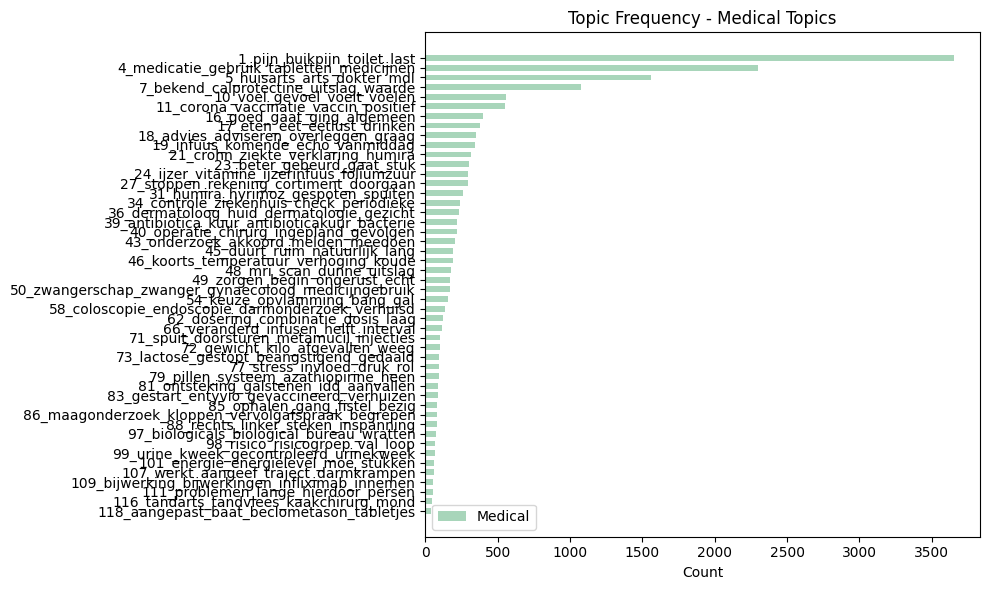

In [249]:
import matplotlib.pyplot as plt

# Filter only "M" topics
df_m = topic_info[topic_info["Label"] == "M"]

# Sort the topics by count in ascending order
df_m = df_m.sort_values(by="Count", ascending=True)

# Create a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_m["Name"], df_m["Count"], color='#A8D5BA', label='Medical', height=0.6)  # Soft green

# Add labels and title
ax.set_xlabel('Count')
ax.set_title('Topic Frequency - Medical Topics')
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [250]:
df_m

,Topic,Count,Name,Representation,Representative_Docs,Label
119,118,39,118_aangepast_baat_beclometason_tabletjes,"[aangepast, baat, beclometason, tabletjes, middel, nachtrust, weerstand, beviel, concluderen, echinacea]","[Zou dit ook nog aangepast kunnen worden?, De gezondheidspremie wordt aangepast., Ik heb hier toch veel meer baat bij dan bij de Beclometason 3x per week en nu gaat het goed met de klachten.]",M
117,116,45,116_tandarts_tandvlees_kaakchirurg_mond,"[tandarts, tandvlees, kaakchirurg, mond, kies, tanden, verwezen, acute, ontsteking, tong]","[Morgen ga ik hiervoor naar de tandarts., Afspraak met tandarts is inmiddels gemaakt., 2 juni a.s. krijg ik een wortelkanaalbehandeling bij de tandarts.]",M
112,111,51,111_problemen_lange_hierdoor_persen,"[problemen, lange, hierdoor, persen, onderdrukt, stimuleren, activiteit, buurt, fulltime, verklaren]","[Ik heb zelf het idee dat de cortiment de reumatische klachten lange tijd onderdrukt heeft en deze, nu ik hiermee gestopt ben, weer tot uiting komen., Echt problemen met de darmen heb ik niet., Ik...",M
110,109,56,109_bijwerking_bijwerkingen_infliximab_innemen,"[bijwerking, bijwerkingen, infliximab, innemen, concentreren, budosenide, flagyl, gewichtstoename, bijsluiter, ofwel]","[Is dit een bijwerking van het infuus?, Weet namelijk niet of dit een bijwerking kan zijn., Is dat een bijwerking bij die medicatie?]",M
108,107,58,107_werkt_aangeef_traject_darmkrampen,"[werkt, aangeef, traject, darmkrampen, valt, interpreteren, zit, inenting, afspreken, regel]","[Prednisolon werkt., Als huishoudfolie ook werkt dan gebruik ik deze., Hoe werkt dit eigenlijk precies.]",M
102,101,63,101_energie_energielevel_moe_stukken,"[energie, energielevel, moe, stukken, aant, krijgt, richting, energieniveau, hormonen, eet]","[Ik heb veel minder buikpijn en heb ook meer energie., wel heb ik iets meer energie., Wel iets meer energie.]",M
100,99,67,99_urine_kweek_gecontroleerd_urinekweek,"[urine, kweek, gecontroleerd, urinekweek, urineweginfectie, constateren, blaas, snappen, infectie, gezet]","[Moet ik ook ontlasting en urine ,mee nemen ., Huisarts heeft urine op kweek laten zetten., Is er al een uitslag vd urine kweek?]",M
99,98,68,98_risico_risicogroep_val_loop,"[risico, risicogroep, val, loop, behoor, groep, bso, trigger, lopen, prikdienst]","[Loop ik dan nog meer verhoogd risico., Loop ik extra risico?, Kan ik het risico nemen?]",M
98,97,72,97_biologicals_biological_bureau_wratten,"[biologicals, biological, bureau, wratten, weekse, biopsie, starten, aangetroffen, plekke, switchen]","[Biologicals bureau., Kan ik dit bij de biologicals inleveren?, ik gebruik biologicals humira.]",M
89,88,81,88_rechts_linker_steken_inspanning,"[rechts, linker, steken, inspanning, handen, voeten, linkerkant, nier, onderste, name]","[Bij inspanning vaker last van steken aan linkerzijde buik (vergelijkbaar met steken tijdens opvlamming)., Bij inspanning vaker last van steken aan linkerzijde buik (vergelijkbaar met steken tijde...",M


In [251]:
df_m["Name"].to_list()

['118_aangepast_baat_beclometason_tabletjes',
 '116_tandarts_tandvlees_kaakchirurg_mond',
 '111_problemen_lange_hierdoor_persen',
 '109_bijwerking_bijwerkingen_infliximab_innemen',
 '107_werkt_aangeef_traject_darmkrampen',
 '101_energie_energielevel_moe_stukken',
 '99_urine_kweek_gecontroleerd_urinekweek',
 '98_risico_risicogroep_val_loop',
 '97_biologicals_biological_bureau_wratten',
 '88_rechts_linker_steken_inspanning',
 '86_maagonderzoek_kloppen_vervolgafspraak_begrepen',
 '85_ophalen_gang_fistel_bezig',
 '83_gestart_entyvio_gevaccineerd_verhuizen',
 '81_ontsteking_galstenen_idd_aanvallen',
 '79_pillen_systeem_azathiopirine_heen',
 '77_stress_invloed_druk_rol',
 '73_lactose_gestopt_beangstigend_gedaald',
 '72_gewicht_kilo_afgevallen_weeg',
 '71_spuit_doorsturen_metamucil_injecties',
 '66_veranderd_infusen_helft_interval',
 '62_dosering_combinatie_dosis_laag',
 '58_coloscopie_endoscopie_darmonderzoek_verhuisd',
 '54_keuze_opvlamming_bang_gal',
 '50_zwangerschap_zwanger_gynaecoloog_m

## Visualize data